In [186]:
#Import packages
#---------------------------------------
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import matplotlib
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import glob
import admin_functions as adfn
import trace_analyse as tfn
from tqdm import tqdm
import re

In [2]:
#Generic functions
#=========================
def fish_id_from_path(p):
    b = os.path.basename(p)
    m = re.search(r"(BLNDEV-WILDTYPE-\d+)", b)
    return m.group(1) if m else os.path.splitext(b)[0]

def parse_age_dpf(path):
    # expects "...-4dpf..." or "... 4dpf ..." etc; adjust to your filename convention
    m = re.search(r"(\d+)\s*dpf", path)
    if m:
        return int(m.group(1))
    m = re.search(r"(\d+)dpf", path)
    return int(m.group(1)) if m else np.nan

# ICG

In [177]:
#ICG
import numpy as np

# ============================================================
# Fast greedy ICG (Iterative Coarse-Graining) for X: (N, T)
# - Greedy pairing by Pearson correlation at each generation
# - Returns:
#   generations: list[int]
#   labels_by_gen: list[np.ndarray]  (each: (N_original,) cluster id at that generation)
#   mean_traces_by_gen: list[np.ndarray] (each: (n_clusters_gen, T) mean trace per cluster)
#   sizes_by_gen: list[np.ndarray]  (each: (n_clusters_gen,) #cells per cluster)
#
# Notes:
# - This is "fast" in the sense that each generation uses a single BLAS matmul to
#   form the correlation matrix, and greedy pairing runs without sorting edges.
# - Memory: correlation matrix at gen0 is ~N^2 float32 (N=10k -> ~400MB).
# ============================================================

def _zscore_rows(X, eps=1e-6):
    """Row-wise z-score in float32."""
    X = np.asarray(X, dtype=np.float32, order="C")
    mu = X.mean(axis=1, keepdims=True)
    Xc = X - mu
    sd = Xc.std(axis=1, keepdims=True)
    return Xc / (sd + eps)

def _greedy_pairs_from_corr_inplace(C):
    """
    Greedy pairing from correlation matrix C (modified in-place):
      - pick i in order; pair with argmax(C[i]) among remaining.
      - when i,j paired: set rows/cols i,j to -inf so they cannot be reused.
    Returns:
      pairs: (P, 2) int32 with i<j
      singles: (S,) int32 remaining (if odd n)
    """
    n = C.shape[0]
    pairs = []
    alive = np.ones(n, dtype=bool)

    # diagonal cannot pair with itself
    np.fill_diagonal(C, -np.inf)

    for i in range(n):
        if not alive[i]:
            continue

        j = int(np.argmax(C[i]))  # columns of dead nodes have been set to -inf
        if (j == i) or (not alive[j]) or (not np.isfinite(C[i, j])):
            # couldn't find a partner (should only happen if n==1)
            continue

        a, b = (i, j) if i < j else (j, i)
        pairs.append((a, b))

        # kill both nodes
        alive[i] = False
        alive[j] = False

        # remove them from further consideration: set rows+cols to -inf
        C[i, :] = -np.inf
        C[:, i] = -np.inf
        C[j, :] = -np.inf
        C[:, j] = -np.inf

    pairs = np.asarray(pairs, dtype=np.int32)
    singles = np.where(alive)[0].astype(np.int32)
    return pairs, singles

def icg_greedy_fast(
    X,
    n_gen=None,
    eps=1e-6,
    keep_singletons=True,
    return_gen0=True,
    verbose=False,
):
    """
    Parameters
    ----------
    X : array (N, T)
        Per-cell traces (can be dff, deconvolved, etc).
    n_gen : int or None
        Number of coarse-graining generations to compute (None -> until 1 cluster).
    eps : float
        Stabilizer for z-scoring.
    keep_singletons : bool
        If odd number of units at some generation, keep last as a singleton.
    return_gen0 : bool
        Include generation 0 outputs (labels=0..N-1, mean_traces=X, sizes=1).
    verbose : bool
        Print progress.

    Returns
    -------
    generations : list[int]
    labels_by_gen : list[np.ndarray]      # each (N_original,)
    mean_traces_by_gen : list[np.ndarray] # each (n_clusters_gen, T)
    sizes_by_gen : list[np.ndarray]       # each (n_clusters_gen,)
    """
    X0 = np.asarray(X, dtype=np.float32, order="C")
    N0, T = X0.shape

    # current level representation: units x T are MEAN traces of underlying cells
    X_curr = X0
    sizes_curr = np.ones(X_curr.shape[0], dtype=np.int32)

    # map original cells -> current unit id (starts as identity)
    labels_curr = np.arange(N0, dtype=np.int32)

    generations = []
    labels_by_gen = []
    mean_traces_by_gen = []
    sizes_by_gen = []

    def _append(gen, labels, traces, sizes):
        generations.append(gen)
        labels_by_gen.append(labels.copy())
        mean_traces_by_gen.append(np.asarray(traces, dtype=np.float32))
        sizes_by_gen.append(sizes.copy())

    gen = 0
    if return_gen0:
        _append(gen, labels_curr, X_curr, sizes_curr)

    # how many gens?
    if n_gen is None:
        # until we reach 1 cluster
        max_gen = 10_000  # hard cap safety
    else:
        max_gen = int(n_gen)

    while gen < max_gen:
        n_units = X_curr.shape[0]
        if n_units <= 1:
            break

        gen += 1
        if verbose:
            print(f"[ICG] gen={gen}  n_units={n_units}")

        # 1) correlation matrix for current units (float32)
        Z = _zscore_rows(X_curr, eps=eps)  # (n_units, T)
        C = (Z @ Z.T) / float(T)          # (n_units, n_units) float32

        # 2) greedy pairing on C in-place
        pairs, singles = _greedy_pairs_from_corr_inplace(C)

        # 3) build children lists for new clusters
        if pairs.size == 0 and singles.size == n_units:
            # nothing could be paired (shouldn't happen, but guard)
            if verbose:
                print("[ICG] no pairs formed; stopping.")
            break

        # Decide how to handle singles
        if (not keep_singletons) and (singles.size > 0):
            # drop the singles
            singles = np.empty((0,), dtype=np.int32)

        P = pairs.shape[0]
        S = singles.shape[0]
        n_new = P + S

        # children indices
        a = np.empty(n_new, dtype=np.int32)
        b = np.empty(n_new, dtype=np.int32)

        # pairs first
        if P > 0:
            a[:P] = pairs[:, 0]
            b[:P] = pairs[:, 1]

        # singletons: represent as (s, s) but with weight_b=0
        if S > 0:
            a[P:] = singles
            b[P:] = singles

        # 4) update cluster sizes
        sa = sizes_curr[a].astype(np.float32)
        sb = sizes_curr[b].astype(np.float32)
        if S > 0:
            # zero out sb for singleton rows (so mean stays unchanged)
            sb[P:] = 0.0

        sizes_new = (sa + sb).astype(np.int32)  # (#cells in each new cluster)
        denom = (sa + sb).reshape(-1, 1)        # float32

        # 5) update mean traces (weighted mean of children clusters)
        Xa = X_curr[a]  # (n_new, T)
        Xb = X_curr[b]  # (n_new, T)
        X_new = (sa.reshape(-1, 1) * Xa + sb.reshape(-1, 1) * Xb) / denom

        # 6) mapping old units -> new units (for propagating original-cell labels)
        unit_to_new = np.full(n_units, -1, dtype=np.int32)
        unit_to_new[a] = np.arange(n_new, dtype=np.int32)
        if P > 0:
            unit_to_new[b[:P]] = np.arange(P, dtype=np.int32)  # second child of pairs

        # propagate labels for original cells
        labels_curr = unit_to_new[labels_curr]
        if np.any(labels_curr < 0):
            raise RuntimeError("Label propagation failed (found -1). Check singleton handling.")

        # save outputs at this generation
        _append(gen, labels_curr, X_new, sizes_new)

        # advance
        X_curr = X_new
        sizes_curr = sizes_new

    return generations, labels_by_gen, mean_traces_by_gen, sizes_by_gen

# ============================
# Example usage
# ============================
# X: (N,T) e.g. dff or deconvolved events
# gen, label_l, icgtr_l, size_l = icg_greedy_fast(
#     dff, n_gen=14, eps=1e-6, keep_singletons=True, return_gen0=True, verbose=True
# )
# #
# labels_by_gen[g] gives you an (N,) vector mapping each original cell -> cluster id at gen g
# mean_traces_by_gen[g] is (n_clusters_at_g, T) mean trace for each cluster at gen g
# sizes_by_gen[g] is (#cells in each cluster at gen g)


[ICG] gen=1  n_units=180
[ICG] gen=2  n_units=90
[ICG] gen=3  n_units=45
[ICG] gen=4  n_units=23
[ICG] gen=5  n_units=12
[ICG] gen=6  n_units=6


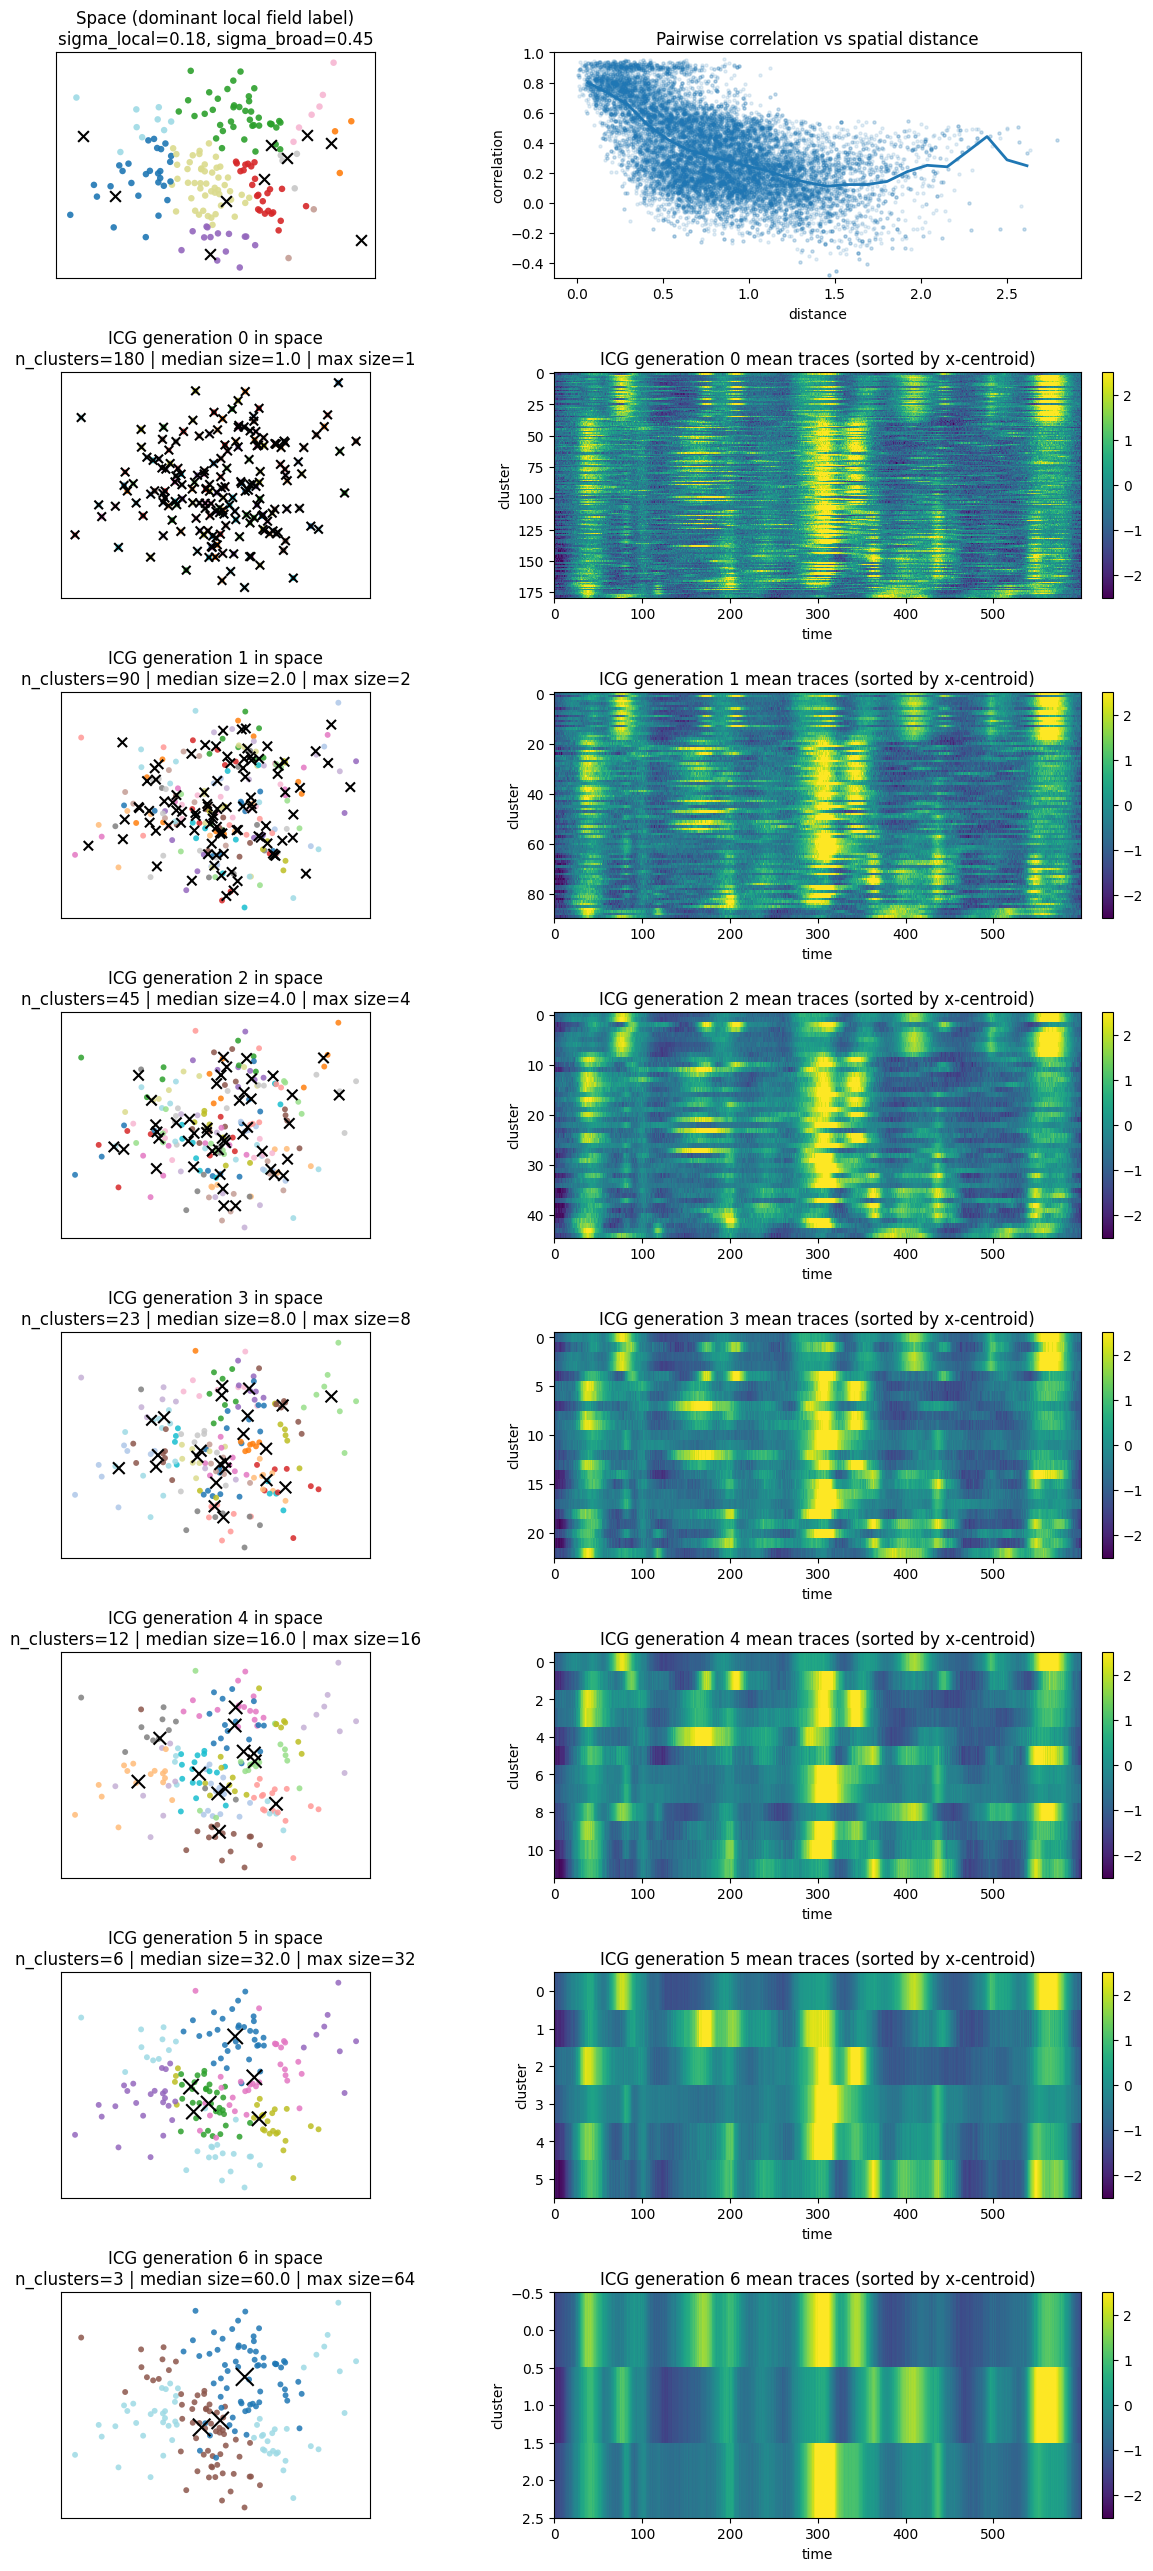

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Smooth toy signals where nearby cells tend to be more correlated
# ------------------------------------------------------------

def _gaussian_smooth_1d(x, sigma=8):
    x = np.asarray(x, dtype=np.float32)
    radius = int(max(3, np.ceil(4 * sigma)))
    t = np.arange(-radius, radius + 1, dtype=np.float32)
    k = np.exp(-(t**2) / (2 * sigma**2))
    k /= k.sum()
    return np.convolve(x, k, mode="same")

def _z1(x, eps=1e-6):
    x = np.asarray(x, dtype=np.float32)
    return (x - x.mean()) / (x.std() + eps)

def _make_latent(T, rng, sigma=10, n_bursts=6):
    """Smooth latent with a few burst-like events."""
    x = rng.normal(size=T).astype(np.float32)
    x = _gaussian_smooth_1d(x, sigma=sigma)

    tt = np.arange(T, dtype=np.float32)
    for _ in range(n_bursts):
        c = rng.integers(20, T - 20)
        w = rng.uniform(4, 18)
        a = rng.uniform(0.8, 2.0)
        x += a * np.exp(-0.5 * ((tt - c) / w) ** 2)

    return _z1(x)

def _rbf_weights(locs, centers, sigma, eps=1e-12):
    """
    RBF weights from each cell location to each latent-field center.
    """
    d2 = ((locs[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    W = np.exp(-d2 / (2 * sigma**2)).astype(np.float32)
    W /= (W.sum(axis=1, keepdims=True) + eps)
    return W

def make_toy_spatial_signals(
    N=180,
    T=600,
    seed=0,
    n_local_fields=10,
    n_broad_fields=4,
    sigma_local=0.18,
    sigma_broad=0.45,
    noise_scale=0.20,
):
    """
    Build traces from continuous spatial latent fields rather than hard groups.

    Nearby cells get similar mixtures of local/broad latent processes, so
    pairwise correlation tends to decrease with spatial distance.

    Returns
    -------
    X : (N,T) float32
        Simulated traces
    locs : (N,2) float32
        2D cell locations
    group_id : (N,) int32
        Dominant local-field label (just for plotting)
    info : dict
        Extra information about the latent fields
    """
    rng = np.random.default_rng(seed)

    # --------------------------------------------------------
    # 1) Cell locations: mildly non-uniform, but not hard clumps
    # --------------------------------------------------------
    # Start from a few density hotspots just to make space look more realistic,
    # but signal smoothness comes from the latent fields below.
    density_centers = rng.uniform(-1, 1, size=(4, 2)).astype(np.float32)
    density_assign = rng.integers(0, len(density_centers), size=N)
    locs = density_centers[density_assign] + 0.28 * rng.normal(size=(N, 2)).astype(np.float32)

    # Small affine distortion
    A = np.array([[1.15, 0.25], [-0.05, 0.95]], dtype=np.float32)
    locs = locs @ A.T

    # --------------------------------------------------------
    # 2) Spatial latent fields
    # --------------------------------------------------------
    local_centers = rng.uniform(locs.min(axis=0) - 0.1, locs.max(axis=0) + 0.1,
                                size=(n_local_fields, 2)).astype(np.float32)
    broad_centers = rng.uniform(locs.min(axis=0) - 0.1, locs.max(axis=0) + 0.1,
                                size=(n_broad_fields, 2)).astype(np.float32)

    W_local = _rbf_weights(locs, local_centers, sigma=sigma_local)
    W_broad = _rbf_weights(locs, broad_centers, sigma=sigma_broad)

    # For visualization only: dominant local field
    group_id = np.argmax(W_local, axis=1).astype(np.int32)

    # --------------------------------------------------------
    # 3) Temporal latent processes
    # --------------------------------------------------------
    global_latent = _make_latent(T, rng, sigma=14, n_bursts=7)

    broad_latents = np.stack(
        [_make_latent(T, rng, sigma=11, n_bursts=6) for _ in range(n_broad_fields)],
        axis=0
    ).astype(np.float32)

    local_latents = np.stack(
        [_make_latent(T, rng, sigma=8, n_bursts=5) for _ in range(n_local_fields)],
        axis=0
    ).astype(np.float32)

    # Give each field a different strength so some regions are more coherent
    broad_amp = rng.uniform(0.6, 1.0, size=n_broad_fields).astype(np.float32)
    local_amp = rng.uniform(0.7, 1.3, size=n_local_fields).astype(np.float32)

    broad_latents = broad_amp[:, None] * broad_latents
    local_latents = local_amp[:, None] * local_latents

    # --------------------------------------------------------
    # 4) Build each cell's trace from its spatially weighted mixture
    # --------------------------------------------------------
    X = []
    for i in range(N):
        local_mix = W_local[i] @ local_latents
        broad_mix = W_broad[i] @ broad_latents
        cell_unique = _make_latent(T, rng, sigma=6, n_bursts=3)

        x = (
            0.20 * global_latent
            + 0.35 * broad_mix
            + 0.75 * local_mix
            + 0.22 * cell_unique
            + noise_scale * rng.normal(size=T)
        )
        X.append(_z1(x))

    X = np.asarray(X, dtype=np.float32)

    # Shuffle so ordering carries no information
    perm = rng.permutation(N)
    X = X[perm]
    locs = locs[perm]
    group_id = group_id[perm]
    W_local = W_local[perm]
    W_broad = W_broad[perm]

    info = {
        "local_centers": local_centers,
        "broad_centers": broad_centers,
        "W_local": W_local,
        "W_broad": W_broad,
        "sigma_local": sigma_local,
        "sigma_broad": sigma_broad,
    }

    return X, locs, group_id, info


# ------------------------------------------------------------
# Plot helpers
# ------------------------------------------------------------

def _cluster_centroids_from_labels(locs, labels):
    labels = np.asarray(labels)
    u, inv = np.unique(labels, return_inverse=True)
    counts = np.bincount(inv)
    cx = np.bincount(inv, weights=locs[:, 0]) / counts
    cy = np.bincount(inv, weights=locs[:, 1]) / counts
    centroids = np.c_[cx, cy]
    return u, inv, counts.astype(np.int32), centroids

def _pairwise_distance_corr(locs, X, n_pairs=12000, seed=0):
    """
    Random subset of pairwise distances and correlations for plotting.
    """
    rng = np.random.default_rng(seed)
    N = X.shape[0]

    i = rng.integers(0, N, size=n_pairs)
    j = rng.integers(0, N, size=n_pairs)
    keep = i != j
    i = i[keep]
    j = j[keep]

    d = np.sqrt(((locs[i] - locs[j]) ** 2).sum(axis=1))
    c = np.sum(X[i] * X[j], axis=1) / X.shape[1]  # since rows are z-scored
    return d, c

def _plot_group_baseline(ax_space, ax_corr, locs, X, group_id, info):
    # space
    ax_space.scatter(
        locs[:, 0], locs[:, 1],
        c=group_id, s=22, alpha=0.9, linewidths=0, cmap="tab20"
    )
    ax_space.scatter(
        info["local_centers"][:, 0], info["local_centers"][:, 1],
        c="k", s=60, marker="x", linewidths=1.5
    )
    ax_space.set_title(
        f"Space (dominant local field label)\n"
        f"sigma_local={info['sigma_local']:.2f}, sigma_broad={info['sigma_broad']:.2f}"
    )
    ax_space.set_aspect("equal")
    ax_space.set_xticks([])
    ax_space.set_yticks([])

    # distance vs correlation
    d, c = _pairwise_distance_corr(locs, X, n_pairs=15000, seed=1)
    ax_corr.scatter(d, c, s=5, alpha=0.12)
    # running mean
    bins = np.linspace(d.min(), d.max(), 25)
    mids = 0.5 * (bins[:-1] + bins[1:])
    means = np.full(len(mids), np.nan, dtype=np.float32)
    for k in range(len(mids)):
        m = (d >= bins[k]) & (d < bins[k + 1])
        if np.any(m):
            means[k] = np.mean(c[m])
    ax_corr.plot(mids, means, linewidth=2)
    ax_corr.set_title("Pairwise correlation vs spatial distance")
    ax_corr.set_xlabel("distance")
    ax_corr.set_ylabel("correlation")
    ax_corr.set_ylim(-0.5, 1.0)

def plot_icg_sanity(
    locs,
    X,
    group_id,
    info,
    generations,
    labels_by_gen,
    mean_traces_by_gen,
    sizes_by_gen,
    max_gen_show=6,
):
    """
    Row 0: baseline spatial smoothness
    Rows 1+: each ICG generation
      left  = cells in space colored by current cluster id + centroids
      right = z-scored cluster mean traces
    """
    gens_to_show = [g for g in generations if g <= max_gen_show]
    if len(gens_to_show) == 0:
        gens_to_show = generations[:1]

    nrows = 1 + len(gens_to_show)
    fig, axes = plt.subplots(
        nrows, 2, figsize=(12, 3.2 * nrows), constrained_layout=True
    )
    if nrows == 1:
        axes = np.array([axes])

    # baseline
    _plot_group_baseline(axes[0, 0], axes[0, 1], locs, X, group_id, info)

    # generations
    for row, g in enumerate(gens_to_show, start=1):
        labels = labels_by_gen[g]
        M = mean_traces_by_gen[g]
        sizes = sizes_by_gen[g]

        u, inv, counts, centroids = _cluster_centroids_from_labels(locs, labels)

        # ---- space ----
        ax = axes[row, 0]
        ax.scatter(
            locs[:, 0], locs[:, 1],
            c=inv, s=18, alpha=0.85, linewidths=0, cmap="tab20"
        )
        ax.scatter(
            centroids[:, 0], centroids[:, 1],
            s=20 + 18 * np.sqrt(counts),
            c="k", marker="x", linewidths=1.5
        )
        ax.set_title(
            f"ICG generation {g} in space\n"
            f"n_clusters={len(u)} | median size={np.median(counts):.1f} | max size={counts.max()}"
        )
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

        # ---- signals ----
        # sort clusters by x-centroid so neighboring rows are also spatially nearby-ish
        order = np.argsort(centroids[:, 0])
        M_show = M[order]
        M_show = (M_show - M_show.mean(axis=1, keepdims=True)) / (
            M_show.std(axis=1, keepdims=True) + 1e-6
        )

        ax = axes[row, 1]
        im = ax.imshow(
            M_show,
            aspect="auto",
            interpolation="nearest",
            cmap="viridis",
            vmin=-2.5,
            vmax=2.5
        )
        ax.set_title(f"ICG generation {g} mean traces (sorted by x-centroid)")
        ax.set_xlabel("time")
        ax.set_ylabel("cluster")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    return fig


# ------------------------------------------------------------
# Run the sanity check
# ------------------------------------------------------------

# Make toy data
X, locs, group_id, info = make_toy_spatial_signals(
    N=180,
    T=600,
    seed=4,
    n_local_fields=10,
    n_broad_fields=4,
    sigma_local=0.18,   # smaller -> sharper local similarity
    sigma_broad=0.45,   # larger -> broader shared background
    noise_scale=0.18,   # larger -> weaker distance-correlation structure
)

# Run ICG
generations, labels_by_gen, mean_traces_by_gen, sizes_by_gen = icg_greedy_fast(
    X,
    n_gen=6,
    eps=1e-6,
    keep_singletons=True,
    return_gen0=True,
    verbose=True,
)

# Plot
fig = plot_icg_sanity(
    locs,
    X,
    group_id,
    info,
    generations,
    labels_by_gen,
    mean_traces_by_gen,
    sizes_by_gen,
    max_gen_show=6,
)
plt.show()

In [4]:
#Load in data
fdata = '/home/dburrows/DATA/BLNDEV-WILDTYPE/'

icg_dir = os.path.join(fdata, "icg_npy")
icg_files = np.sort(glob.glob(os.path.join(icg_dir, "*_icg_greedy.npy")))

# sampling rate (your data: 2.73 Hz)
fs = 2.73
dt = 1.0 / fs

In [7]:
curr_dic = np.load(icg_files[0], allow_pickle=True).item()
curr_dic.keys()

dict_keys(['generations', 'labels_by_gen', 'mean_traces_by_gen', 'sizes_by_gen', 'source_path'])

In [42]:
curr_dic['generations']

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int32)

In [48]:
curr_dic['labels_by_gen']

array([[0, 1, 2, ..., 15102, 15103, 15104],
       [0, 1, 2, ..., 7287, 6995, 6468],
       [0, 1, 2, ..., 3693, 669, 3470],
       ...,
       [0, 1, 2, ..., 2, 1, 1],
       [0, 1, 0, ..., 0, 1, 1],
       [0, 0, 0, ..., 0, 0, 0]], shape=(15, 15105), dtype=object)

In [50]:
curr_dic['mean_traces_by_gen']

array([array([[9.4823895e+00, 5.0931611e+00, 3.0400481e+00, ..., 4.2297578e+00,
               2.3856091e+00, 1.4458393e+00],
              [3.1046016e+00, 2.0605907e+00, 1.3887314e+00, ..., 2.0052850e+00,
               7.1711868e-01, 3.0137532e+00],
              [3.6856285e-01, 8.1535835e+00, 8.9922457e+00, ..., 7.8474637e-03,
               3.6546905e+00, 3.6446344e-02],
              ...,
              [7.9718752e+00, 4.9124970e+00, 1.9383972e+00, ..., 4.5102310e+00,
               0.0000000e+00, 6.5370860e+00],
              [0.0000000e+00, 7.8676772e-01, 1.2850186e-01, ..., 6.0690027e-01,
               2.1972655e-01, 5.7116312e-01],
              [1.8558626e+01, 1.2047205e-01, 8.5609752e-01, ..., 1.5277401e+00,
               5.9350818e-01, 9.7401834e-01]], shape=(15105, 4914), dtype=float32),
       array([[ 4.7411947 ,  6.147272  ,  3.8255267 , ...,  2.114879  ,
                1.8065906 ,  3.8857894 ],
              [ 1.6740581 ,  5.7901516 ,  6.95846   , ...,  7.9058065 ,
 

In [51]:
curr_dic['sizes_by_gen']

array([array([1, 1, 1, ..., 1, 1, 1], shape=(15105,), dtype=int32),
       array([2, 2, 2, ..., 2, 2, 1], shape=(7553,), dtype=int32),
       array([4, 4, 4, ..., 4, 4, 2], shape=(3777,), dtype=int32),
       array([8, 8, 8, ..., 8, 8, 2], shape=(1889,), dtype=int32),
       array([16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
              16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
              16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
              16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
              16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
              16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
              16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
              16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
              16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 1

In [138]:
df = pd.read_csv(f"{fdata}/NEW_icg_metrics_by_fish_gen.csv")

# kurtosis

In [5]:
#======================
def kurtosis_corr(data):
#======================
    corr = np.corrcoef(data)
    x = corr[np.triu_indices(corr.shape[0], k=1)]
    
    #kurtosis 
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size < 10:
        return np.nan
    m = x.mean()
    v = x.var()
    if v <= 0:
        return np.nan
    return np.mean((x - m) ** 4) / (v ** 2)




In [8]:
%%time
inp = curr_dic['mean_traces_by_gen'][0]
kurt = kurtosis_corr(inp)

CPU times: user 45.3 s, sys: 436 ms, total: 45.7 s
Wall time: 7.89 s


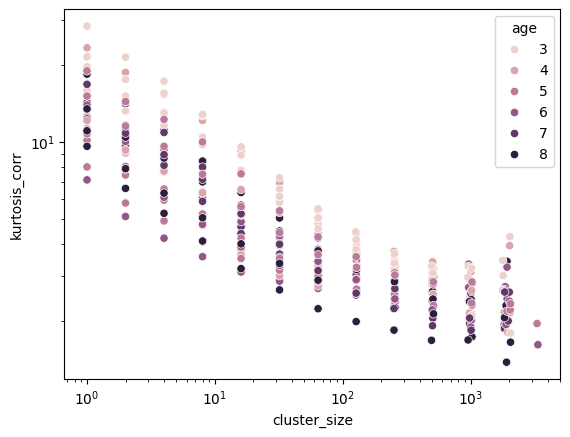

In [128]:
import seaborn as sns
sns.scatterplot(data=df, x = 'cluster_size', y = 'kurtosis_corr', hue = 'age')
plt.yscale('log')
plt.xscale('log')
plt.show()

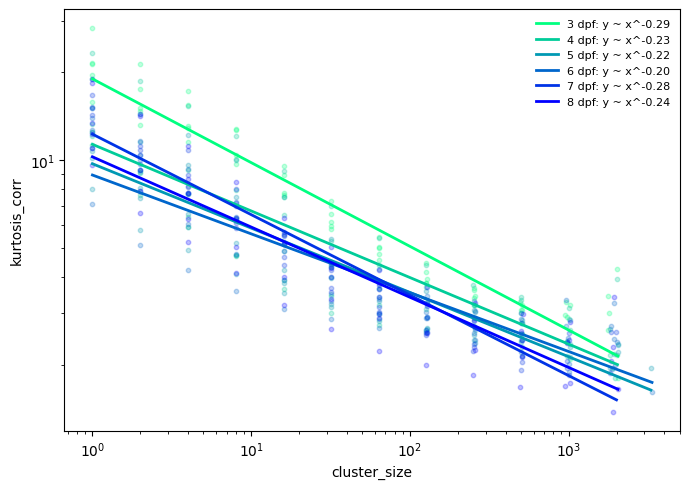

In [80]:
import numpy as np
import matplotlib.pyplot as plt

metric = "kurtosis_corr"
xcol = "cluster_size"

d = df[[xcol, metric, "age"]].dropna().copy()
d = d[(d[xcol] > 0) & (d[metric] > 0)]

ages = np.sort(d["age"].unique())
cmap = plt.get_cmap("winter_r", len(ages))

fig, ax = plt.subplots(figsize=(7, 5))

for k, age in enumerate(ages):
    col = cmap(k)
    sub = d[d["age"] == age].sort_values(xcol)

    lx = np.log10(sub[xcol].values)
    ly = np.log10(sub[metric].values)
    m, b = np.polyfit(lx, ly, 1)

    xfit = np.logspace(lx.min(), lx.max(), 200)
    yfit = 10**(m * np.log10(xfit) + b)

    ax.scatter(sub[xcol], sub[metric], s=10, alpha=0.25, color=col)
    ax.plot(xfit, yfit, color=col, lw=2, label=f"{int(age)} dpf: y ~ x^{m:.2f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(xcol)
ax.set_ylabel(metric)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                   logy   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     557.1
Date:                Sat, 28 Mar 2026   Prob (F-statistic):          1.85e-134
Time:                        15:43:41   Log-Likelihood:                 260.42
No. Observations:                 362   AIC:                            -512.8
Df Residuals:                     358   BIC:                            -497.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2605      0.040     31.743      0.0

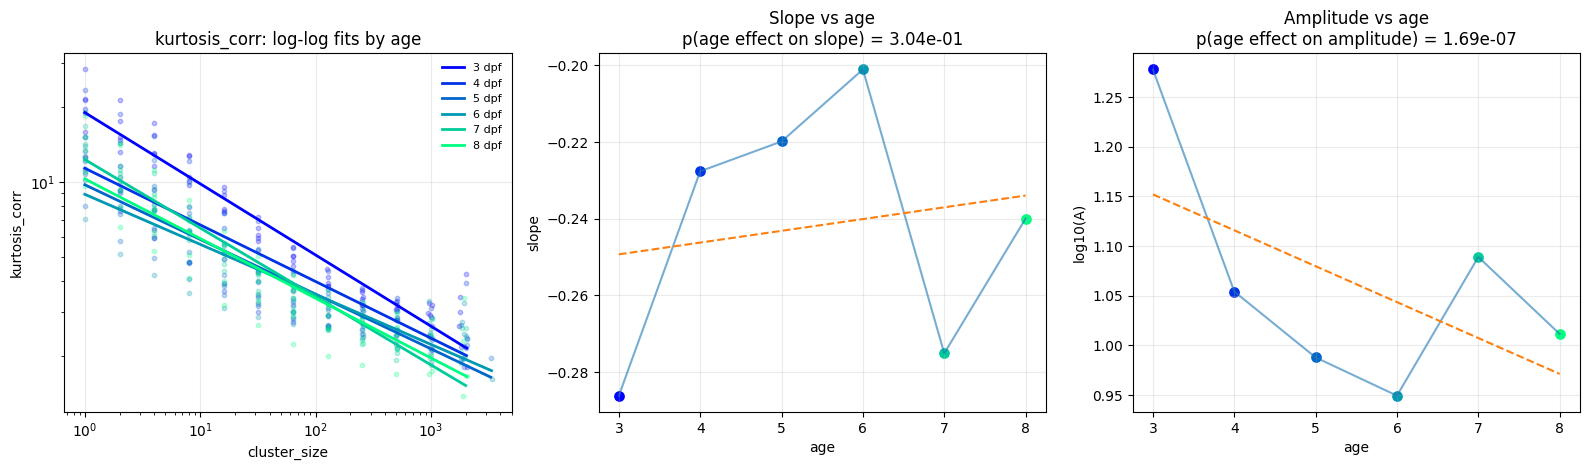

,age,slope,logA,A,n
0,3,-0.286150,1.277841,18.960100,60
1,4,-0.227618,1.054181,11.328714,60
2,5,-0.219845,0.987831,9.723688,73
3,6,-0.201059,0.949334,8.898843,61
4,7,-0.275101,1.089012,12.274720,48
5,8,-0.239948,1.011486,10.267998,60


In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

metric = "kurtosis_corr"
xcol = "cluster_size"

# --------------------------------
# prep
# --------------------------------
d = df[[xcol, metric, "age"]].dropna().copy()
d = d[(d[xcol] > 0) & (d[metric] > 0)].copy()

d["logx"] = np.log10(d[xcol])
d["logy"] = np.log10(d[metric])

ages = np.sort(d["age"].unique())
cmap = plt.get_cmap("winter", len(ages))

# --------------------------------
# per-age fits
# --------------------------------
rows = []

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
ax_fit, ax_slope, ax_amp = axes

for k, age in enumerate(ages):
    col = cmap(k)
    sub = d[d["age"] == age].sort_values(xcol)

    if len(sub) < 3:
        continue

    # fit: log10(y) = m*log10(x) + b
    m, b = np.polyfit(sub["logx"].values, sub["logy"].values, 1)

    # fitted curve back in original space
    xfit = np.logspace(sub["logx"].min(), sub["logx"].max(), 200)
    yfit = 10 ** (m * np.log10(xfit) + b)

    # raw + fit
    ax_fit.scatter(sub[xcol], sub[metric], s=10, alpha=0.25, color=col)
    ax_fit.plot(xfit, yfit, color=col, lw=2, label=f"{int(age)} dpf")

    rows.append({
        "age": age,
        "slope": m,
        "logA": b,
        "A": 10**b,
        "n": len(sub)
    })

coeffs = pd.DataFrame(rows).sort_values("age")

# --------------------------------
# plot slopes / amplitudes by age
# --------------------------------
for k, row in coeffs.reset_index(drop=True).iterrows():
    col = cmap(k)
    ax_slope.scatter(row["age"], row["slope"], color=col, s=45)
    ax_amp.scatter(row["age"], row["logA"], color=col, s=45)

# join with line for readability
ax_slope.plot(coeffs["age"], coeffs["slope"], alpha=0.6)
ax_amp.plot(coeffs["age"], coeffs["logA"], alpha=0.6)

# --------------------------------
# stats tests for age effect
# --------------------------------
# Global model in log space:
#   logy ~ logx + age + logx:age
# age       -> effect on intercept / amplitude
# logx:age  -> effect on slope
model = smf.ols("logy ~ logx * age", data=d).fit()

p_amp = model.pvalues["age"]
p_slope = model.pvalues["logx:age"]

print(model.summary())
print(f"\nP-value for age effect on amplitude/intercept: {p_amp:.3e}")
print(f"P-value for age effect on slope: {p_slope:.3e}")

# optional fitted trend lines on summary panels
if len(coeffs) >= 2:
    ms, bs = np.polyfit(coeffs["age"], coeffs["slope"], 1)
    ma, ba = np.polyfit(coeffs["age"], coeffs["logA"], 1)

    agefit = np.linspace(coeffs["age"].min(), coeffs["age"].max(), 200)
    ax_slope.plot(agefit, ms*agefit + bs, "--", lw=1.5)
    ax_amp.plot(agefit, ma*agefit + ba, "--", lw=1.5)

# --------------------------------
# formatting
# --------------------------------
ax_fit.set_xscale("log")
ax_fit.set_yscale("log")
ax_fit.set_xlabel(xcol)
ax_fit.set_ylabel(metric)
ax_fit.set_title(f"{metric}: log-log fits by age")
ax_fit.legend(frameon=False, fontsize=8)

ax_slope.set_xlabel("age")
ax_slope.set_ylabel("slope")
ax_slope.set_title(f"Slope vs age\np(age effect on slope) = {p_slope:.2e}")

ax_amp.set_xlabel("age")
ax_amp.set_ylabel("log10(A)")
ax_amp.set_title(f"Amplitude vs age\np(age effect on amplitude) = {p_amp:.2e}")

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

coeffs

# Variance

In [123]:
#======================
def mean_variance(data, ntrace, K):
#======================
    if data.size < 10:
        return np.nan
    
    var = sum(np.var(data, axis=1))/ntrace

    return var, var*K**2

In [10]:
inp = curr_dic['mean_traces_by_gen'][0]
mean_variance(inp, inp.shape[0])

np.float32(62.91645)

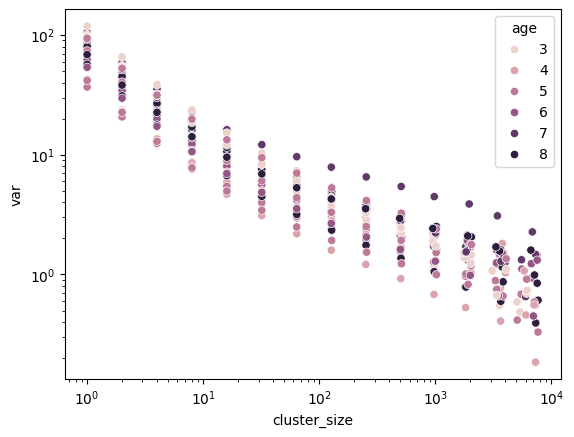

In [131]:
import seaborn as sns
sns.scatterplot(data=df, x = 'cluster_size', y = 'var', hue = 'age')
plt.yscale('log')
plt.xscale('log')
plt.show()

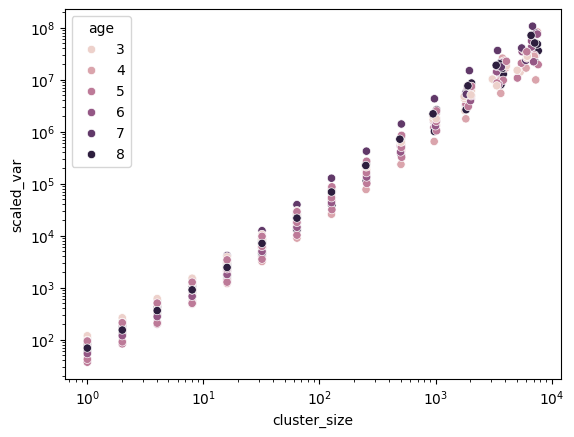

In [140]:
import seaborn as sns
sns.scatterplot(data=df, x = 'cluster_size', y = 'scaled_var', hue = 'age')
plt.yscale('log')
plt.xscale('log')
plt.show()

In [143]:
df['ind'] = [df.iloc[i]['fish'] + '_' + str(df.iloc[i]['age']) for i in range(len(df))]
subdf = df.copy()
subdf.set_index('ind', inplace=True)
vardf = subdf[subdf['gen'] == 0]['scaled_var']
df['scaled_var_norm'] = df['scaled_var'] / vardf.loc[df['ind']].values

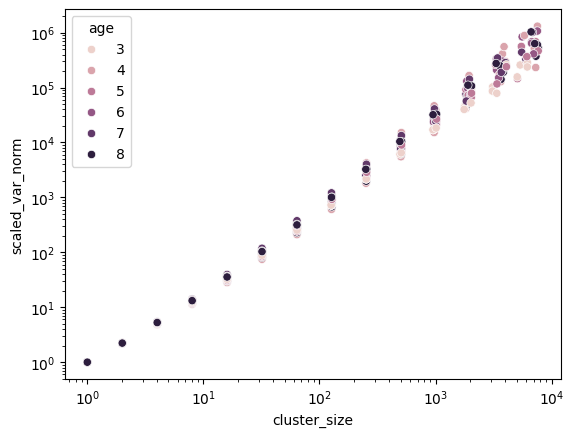

In [144]:
import seaborn as sns
sns.scatterplot(data=df, x = 'cluster_size', y = 'scaled_var_norm', hue = 'age')
plt.yscale('log')
plt.xscale('log')
plt.show()

                            OLS Regression Results                            
Dep. Variable:                   logy   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 2.655e+04
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:34:12   Log-Likelihood:                 253.98
No. Observations:                 420   AIC:                            -500.0
Df Residuals:                     416   BIC:                            -483.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1669      0.042     -3.995      0.0

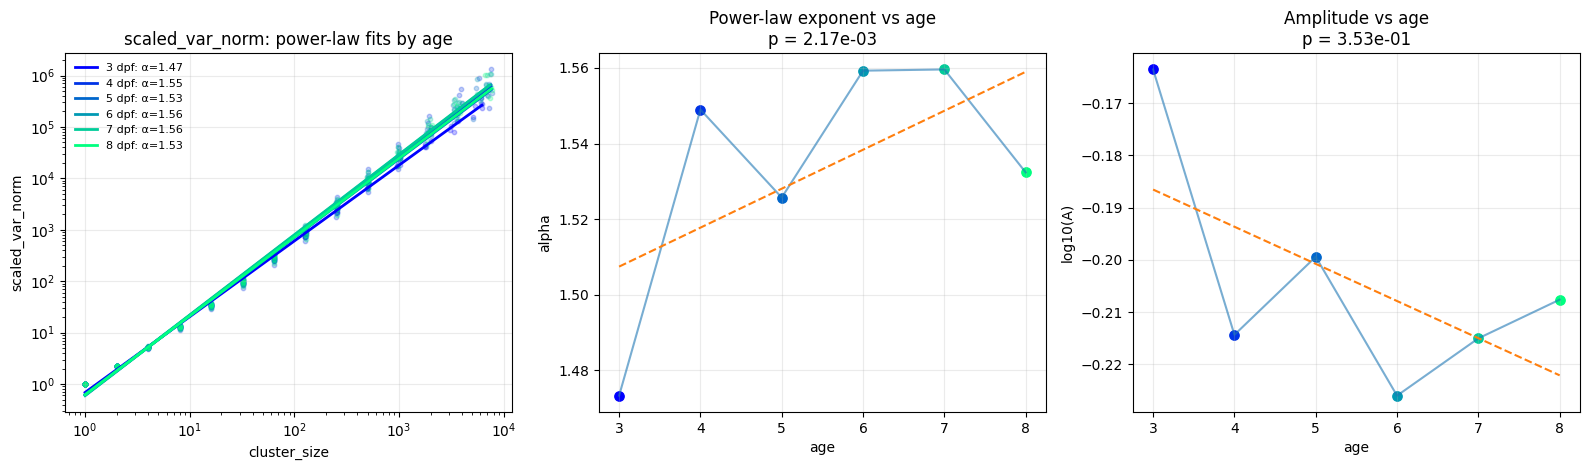

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

metric = "scaled_var_norm"
xcol = "cluster_size"

# --------------------------------
# prep
# --------------------------------
d = df[[xcol, metric, "age"]].dropna().copy()
d = d[(d[xcol] > 0) & (d[metric] > 0)].copy()

d["logx"] = np.log10(d[xcol])
d["logy"] = np.log10(d[metric])

ages = np.sort(d["age"].unique())
cmap = plt.get_cmap("winter", len(ages))

# --------------------------------
# per-age power-law fits
# log10(y) = alpha*log10(x) + log10(A)
# so y = A * x^alpha
# --------------------------------
rows = []

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
ax_fit, ax_slope, ax_amp = axes

for k, age in enumerate(ages):
    col = cmap(k)
    sub = d[d["age"] == age].sort_values(xcol)

    if len(sub) < 3:
        continue

    alpha, logA = np.polyfit(sub["logx"].values, sub["logy"].values, 1)
    A = 10**logA

    xfit = np.logspace(sub["logx"].min(), sub["logx"].max(), 200)
    yfit = A * (xfit ** alpha)

    ax_fit.scatter(sub[xcol], sub[metric], s=10, alpha=0.25, color=col)
    ax_fit.plot(xfit, yfit, color=col, lw=2,
                label=f"{int(age)} dpf: α={alpha:.2f}")

    rows.append({
        "age": age,
        "alpha": alpha,
        "logA": logA,
        "A": A,
        "n": len(sub)
    })

coeffs = pd.DataFrame(rows).sort_values("age")

# --------------------------------
# plot alpha / amplitude by age
# --------------------------------
for k, row in coeffs.reset_index(drop=True).iterrows():
    col = cmap(k)
    ax_slope.scatter(row["age"], row["alpha"], color=col, s=45)
    ax_amp.scatter(row["age"], row["logA"], color=col, s=45)

ax_slope.plot(coeffs["age"], coeffs["alpha"], alpha=0.6)
ax_amp.plot(coeffs["age"], coeffs["logA"], alpha=0.6)

# --------------------------------
# stats tests for age effect
# Global power-law model:
#   log10(y) = log10(A) + alpha*log10(x)
# allowing both amplitude and slope to vary with age:
#   logy ~ logx * age
# --------------------------------
model = smf.ols("logy ~ logx * age", data=d).fit()

p_amp = model.pvalues["age"]
p_slope = model.pvalues["logx:age"]

print(model.summary())
print(f"\nP-value for age effect on amplitude/intercept: {p_amp:.3e}")
print(f"P-value for age effect on slope/exponent: {p_slope:.3e}")

# optional trend lines
if len(coeffs) >= 2:
    m1, b1 = np.polyfit(coeffs["age"], coeffs["alpha"], 1)
    m2, b2 = np.polyfit(coeffs["age"], coeffs["logA"], 1)

    agefit = np.linspace(coeffs["age"].min(), coeffs["age"].max(), 200)
    ax_slope.plot(agefit, m1 * agefit + b1, "--", lw=1.5)
    ax_amp.plot(agefit, m2 * agefit + b2, "--", lw=1.5)

# --------------------------------
# formatting
# --------------------------------
ax_fit.set_xscale("log")
ax_fit.set_yscale("log")
ax_fit.set_xlabel(xcol)
ax_fit.set_ylabel(metric)
ax_fit.set_title(f"{metric}: power-law fits by age")
ax_fit.legend(frameon=False, fontsize=8)

ax_slope.set_xlabel("age")
ax_slope.set_ylabel("alpha")
ax_slope.set_title(f"Power-law exponent vs age\np = {p_slope:.2e}")

ax_amp.set_xlabel("age")
ax_amp.set_ylabel("log10(A)")
ax_amp.set_title(f"Amplitude vs age\np = {p_amp:.2e}")

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [172]:
import numpy as np
import pandas as pd

def compare_age_powerlaw_real_vs_nulls(
    df_null: pd.DataFrame,
    metric: str = "var_norm",
    nulls: tuple = ("real", "dep_shuffle", "indep_circperm"),
    xcol: str = "x_mean_size_gen",
    collapse_null_sims: bool = True,
    collapse_how: str = "median",
    Kmin: int = 50,
    min_obs_per_fish: int = 3,
    q_lo: float = 0.05,
    q_hi: float = 0.95,
) -> pd.DataFrame:
    rows = []

    for null_name in nulls:
        df_sub = df_null[df_null["null"] == null_name].copy()

        if collapse_null_sims and null_name != "real":
            df_sub = collapse_null_sims_within_fish_gen(
                df_sub, metric=metric, xcol=xcol, how=collapse_how
            )

        res = test_age_effects_interaction(
            df_sub,
            metric,
            xcol=xcol,
            fish_id_col="id",
            age_col="age",
            Kmin=Kmin,
            min_obs_per_fish=min_obs_per_fish,
            q_lo=q_lo,
            q_hi=q_hi,
        )

        rows.append({
            "null": null_name,
            "n_fish": res["n_fish"],
            "n_points": res["n_points"],
            "beta_age_amp": res["beta_age_amp"],
            "p_age_amp": res["p_age_amp"],
            "beta_age_slope": res["beta_age_slope"],
            "p_age_slope": res["p_age_slope"],
        })

    out = pd.DataFrame(rows).sort_values("null").reset_index(drop=True)
    return out

In [173]:
cmp_var = compare_age_powerlaw_real_vs_nulls(
    df_null,
    metric="var_norm",
    nulls=("real", "dep_shuffle", "indep_circperm"),
    xcol="x_mean_size_gen",   # or "cluster_size" if that is your column
    collapse_null_sims=True,
    collapse_how="median",
    Kmin=50,
    min_obs_per_fish=3,
)

print(cmp_var)

NameError: name 'df_null' is not defined

# Timescale

In [11]:
import numpy as np

def mean_autocorr_curve(X, max_lag_frames=10, eps=1e-8):
    X = np.asarray(X, dtype=np.float64)
    if X.ndim != 2:
        return None

    N, T = X.shape
    L = min(max_lag_frames, T - 2)
    if N < 1 or L < 1:
        return None

    ac_sum = np.zeros(L + 1, dtype=np.float64)
    n_used = 0

    for i in range(N):
        x = X[i]

        # safer than removing bad points and compressing time
        if not np.all(np.isfinite(x)):
            continue
        if x.size < L + 2:
            continue

        x = x - x.mean()
        v = x.var(ddof=0)
        if v < eps:
            continue

        x = x / np.sqrt(v)

        ac = np.empty(L + 1, dtype=np.float64)
        ac[0] = 1.0
        for lag in range(1, L + 1):
            ac[lag] = np.dot(x[:-lag], x[lag:]) / (x.size - lag)

        ac_sum += ac
        n_used += 1

    if n_used == 0:
        return None

    return ac_sum / n_used


def timescale(X, max_lag=3.0, dt=1.0):
    max_lag_frames = int(np.floor(max_lag / dt))
    ac_mean = mean_autocorr_curve(X, max_lag_frames=max_lag_frames)
    if ac_mean is None:
        return np.nan

    t = np.arange(ac_mean.size) * dt
    return float(np.trapz(ac_mean, t))

In [13]:
inp = curr_dic['mean_traces_by_gen'][0]
timescale(inp, max_lag=3, dt=dt)

/tmp/ipykernel_2062174/1527053791.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ac_mean, t))


0.694566243316932

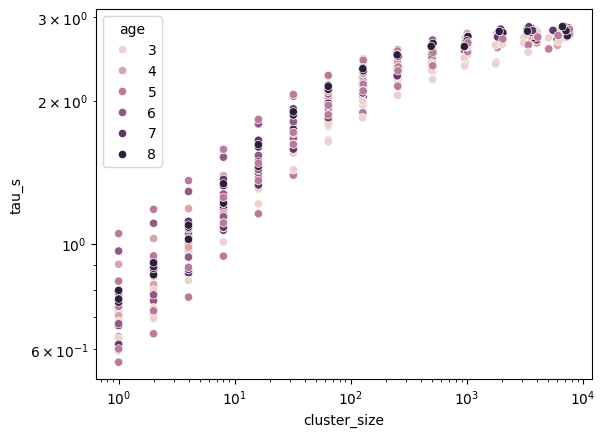

In [151]:
import seaborn as sns
sns.scatterplot(data=df, x = 'cluster_size', y = 'tau_s', hue = 'age')
plt.yscale('log')
plt.xscale('log')
plt.show()

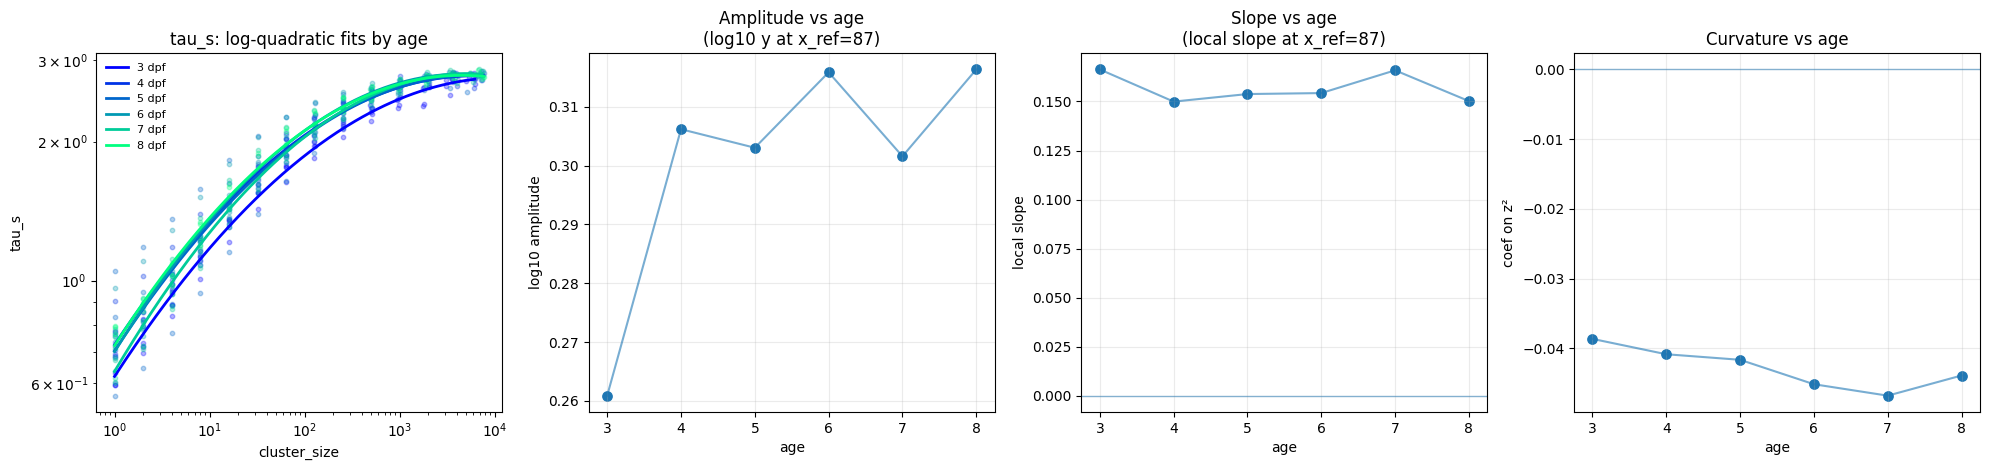

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --------------------------------------------------
# prep
# --------------------------------------------------
def prep_metric_for_logquad(
    df,
    metric="tau_s",
    xcol="cluster_size",
    fish_id_col="name",
    age_col="age",
    min_obs_per_fish=3,
):
    req = [fish_id_col, age_col, xcol, metric]
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    d = df[req].copy()
    d[age_col] = pd.to_numeric(d[age_col], errors="coerce")
    d[xcol] = pd.to_numeric(d[xcol], errors="coerce")
    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    d = d.dropna()

    # log-log fit needs positive values
    d = d[(d[xcol] > 0) & (d[metric] > 0)].copy()

    # aggregate within fish at each x
    d2 = (
        d.groupby([fish_id_col, age_col, xcol], as_index=False)
         .agg(y=(metric, "mean"))
    )

    # require enough x-points per fish
    keep = d2.groupby(fish_id_col).size()
    keep = keep[keep >= min_obs_per_fish].index
    d2 = d2[d2[fish_id_col].isin(keep)].copy()

    return d2


# --------------------------------------------------
# fit one age
# log10(y) ~ a + b*z + c*z^2
# where z = log10(x) - lx_ref
# --------------------------------------------------
def fit_log_quadratic_per_age(dd, xcol="cluster_size", lx_ref=None):
    d2 = dd.copy()
    d2["lx"] = np.log10(d2[xcol].values)
    d2["ly"] = np.log10(d2["y"].values)

    if lx_ref is None:
        lx_ref = d2["lx"].mean()

    d2["z"] = d2["lx"] - lx_ref
    d2["z2"] = d2["z"]**2

    m = smf.ols("ly ~ z + z2", data=d2).fit()

    xfit = np.logspace(np.log10(d2[xcol].min()), np.log10(d2[xcol].max()), 200)
    lxfit = np.log10(xfit)
    zfit = lxfit - lx_ref
    yfit = 10 ** m.predict(pd.DataFrame({"z": zfit, "z2": zfit**2}))

    curve = pd.DataFrame({xcol: xfit, "pred": yfit})

    # interpreted quantities
    logA_ref = m.params.get("Intercept", np.nan)   # log10(y) at x_ref
    A_ref = 10**logA_ref
    slope_ref = m.params.get("z", np.nan)          # d logy / d logx at x_ref
    curvature = m.params.get("z2", np.nan)

    return m, curve, {
        "lx_ref": lx_ref,
        "x_ref": 10**lx_ref,
        "logA_ref": logA_ref,
        "A_ref": A_ref,
        "slope_ref": slope_ref,
        "curvature": curvature,
    }


# --------------------------------------------------
# main plot
# --------------------------------------------------
def plot_age_logquad_metric(
    df,
    metric="tau_s",
    xcol="cluster_size",
    fish_id_col="name",
    age_col="age",
    min_obs_per_fish=3,
    min_fish_per_age=2,
):
    d = prep_metric_for_logquad(
        df,
        metric=metric,
        xcol=xcol,
        fish_id_col=fish_id_col,
        age_col=age_col,
        min_obs_per_fish=min_obs_per_fish,
    )

    ages = np.sort(d[age_col].unique())
    cmap = plt.get_cmap("winter", len(ages))

    # shared reference x across all ages
    lx_ref = np.log10(d[xcol]).mean()
    x_ref = 10**lx_ref

    fig, axes = plt.subplots(1, 4, figsize=(20, 4.8))
    ax_fit, ax_amp, ax_slope, ax_curv = axes

    rows = []

    for k, age in enumerate(ages):
        dd = d[d[age_col] == age].copy()
        if dd[fish_id_col].nunique() < min_fish_per_age:
            continue

        col = cmap(k)

        # raw points
        ax_fit.scatter(dd[xcol], dd["y"], s=10, alpha=0.3, color=col)

        # fit
        m, curve, out = fit_log_quadratic_per_age(dd, xcol=xcol, lx_ref=lx_ref)
        ax_fit.plot(curve[xcol], curve["pred"], lw=2, color=col, label=f"{int(age)} dpf")

        rows.append({
            "age": age,
            "logA_ref": out["logA_ref"],
            "A_ref": out["A_ref"],
            "slope_ref": out["slope_ref"],
            "curvature": out["curvature"],
            "n_fish": dd[fish_id_col].nunique(),
        })

    coeffs = pd.DataFrame(rows).sort_values("age")

    # amplitude vs age
    ax_amp.scatter(coeffs["age"], coeffs["logA_ref"], s=45)
    ax_amp.plot(coeffs["age"], coeffs["logA_ref"], alpha=0.6)
    ax_amp.set_title(f"Amplitude vs age\n(log10 y at x_ref={x_ref:.2g})")
    ax_amp.set_xlabel("age")
    ax_amp.set_ylabel("log10 amplitude")
    ax_amp.grid(True, alpha=0.25)

    # local slope vs age
    ax_slope.scatter(coeffs["age"], coeffs["slope_ref"], s=45)
    ax_slope.plot(coeffs["age"], coeffs["slope_ref"], alpha=0.6)
    ax_slope.axhline(0, lw=1, alpha=0.5)
    ax_slope.set_title(f"Slope vs age\n(local slope at x_ref={x_ref:.2g})")
    ax_slope.set_xlabel("age")
    ax_slope.set_ylabel("local slope")
    ax_slope.grid(True, alpha=0.25)

    # curvature vs age
    ax_curv.scatter(coeffs["age"], coeffs["curvature"], s=45)
    ax_curv.plot(coeffs["age"], coeffs["curvature"], alpha=0.6)
    ax_curv.axhline(0, lw=1, alpha=0.5)
    ax_curv.set_title("Curvature vs age")
    ax_curv.set_xlabel("age")
    ax_curv.set_ylabel("coef on z²")
    ax_curv.grid(True, alpha=0.25)

    # fit panel formatting
    ax_fit.set_xscale("log")
    ax_fit.set_yscale("log")
    ax_fit.set_xlabel(xcol)
    ax_fit.set_ylabel(metric)
    ax_fit.set_title(f"{metric}: log-quadratic fits by age")
    ax_fit.legend(frameon=False, fontsize=8)

    plt.tight_layout()
    plt.show()

    return coeffs


# run
coeffs_quad = plot_age_logquad_metric(
    df,
    metric="tau_s",
    xcol="cluster_size",
    fish_id_col="fish",
    age_col="age",
)

# Mutual information

In [17]:
import numpy as np

def binarize_traces(X, threshold=1.96, per_trace_zscore=True, eps=1e-8):
    """
    X : array, shape (N, T)
        Continuous traces.
    threshold : float
        Threshold for binarization.
    per_trace_zscore : bool
        If True, z-score each trace first, then threshold.
        If False, threshold raw values directly.
    """
    X = np.asarray(X, dtype=np.float64)
    if X.ndim != 2:
        raise ValueError("X must have shape (N, T)")

    if per_trace_zscore:
        mu = X.mean(axis=1, keepdims=True)
        sd = X.std(axis=1, keepdims=True)
        Z = (X - mu) / (sd + eps)
        B = Z > threshold
    else:
        B = X > threshold

    return B.astype(np.uint8)


def _mi_from_binary_counts(n11, s_row, s_col, T, log_base=2):
    """
    Compute MI from binary contingency counts.

    n11 : array, shape (A, B)
        Count of simultaneous 1,1 events for each pair.
    s_row : array, shape (A,)
        Number of ones in row variables.
    s_col : array, shape (B,)
        Number of ones in col variables.
    T : int
        Number of timepoints.
    """
    n11 = np.asarray(n11, dtype=np.float64)
    s_row = np.asarray(s_row, dtype=np.float64)
    s_col = np.asarray(s_col, dtype=np.float64)

    n10 = s_row[:, None] - n11
    n01 = s_col[None, :] - n11
    n00 = T - n11 - n10 - n01

    p11 = n11 / T
    p10 = n10 / T
    p01 = n01 / T
    p00 = n00 / T

    px1 = s_row[:, None] / T
    px0 = 1.0 - px1
    py1 = s_col[None, :] / T
    py0 = 1.0 - py1

    if log_base == 2:
        logf = np.log2
    elif log_base == "e":
        logf = np.log
    else:
        raise ValueError("log_base must be 2 or 'e'")

    mi = np.zeros_like(p11, dtype=np.float64)

    def add_term(pxy, px, py):
        mask = pxy > 0
        out = np.zeros_like(pxy, dtype=np.float64)
        out[mask] = pxy[mask] * logf(pxy[mask] / (px[mask] * py[mask]))
        return out

    mi += add_term(p11, np.broadcast_to(px1, p11.shape), np.broadcast_to(py1, p11.shape))
    mi += add_term(p10, np.broadcast_to(px1, p10.shape), np.broadcast_to(py0, p10.shape))
    mi += add_term(p01, np.broadcast_to(px0, p01.shape), np.broadcast_to(py1, p01.shape))
    mi += add_term(p00, np.broadcast_to(px0, p00.shape), np.broadcast_to(py0, p00.shape))

    return mi


def pairwise_binary_mi(X, threshold=1.96, per_trace_zscore=True,
                       log_base=2, set_diag_nan=True):
    """
    Full pairwise MI matrix.

    Returns
    -------
    mi : array, shape (N, N)
        Pairwise MI matrix.
    B : array, shape (N, T)
        Binarized traces.
    """
    B = binarize_traces(X, threshold=threshold, per_trace_zscore=per_trace_zscore)
    N, T = B.shape

    B32 = B.astype(np.int32, copy=False)
    s = B32.sum(axis=1)

    # n11[i,j] = number of timepoints where both traces are 1
    n11 = B32 @ B32.T

    mi = _mi_from_binary_counts(n11, s, s, T, log_base=log_base)

    if set_diag_nan:
        np.fill_diagonal(mi, np.nan)

    return mi, B


def sampled_pairwise_binary_mi(X, threshold=1.96, per_trace_zscore=True, n_pairs=100_000, seed=0, log_base=2):
    """
    Sample random pairs instead of forming the full N x N MI matrix.
    Good for large N.

    Returns
    -------
    mi_vals : array, shape (n_pairs_kept,)
        MI for sampled pairs.
    pairs : array, shape (n_pairs_kept, 2)
        Pair indices.
    B : array, shape (N, T)
        Binarized traces.
    """
    rng = np.random.default_rng(seed)
    B = binarize_traces(X, threshold=threshold, per_trace_zscore=per_trace_zscore)
    N, T = B.shape

    i = rng.integers(0, N, size=n_pairs)
    j = rng.integers(0, N, size=n_pairs)
    keep = i < j
    i = i[keep]
    j = j[keep]

    Bi = B[i]
    Bj = B[j]

    s_i = Bi.sum(axis=1).astype(np.float64)
    s_j = Bj.sum(axis=1).astype(np.float64)
    n11 = (Bi & Bj).sum(axis=1).astype(np.float64)

    n10 = s_i - n11
    n01 = s_j - n11
    n00 = T - n11 - n10 - n01

    p11 = n11 / T
    p10 = n10 / T
    p01 = n01 / T
    p00 = n00 / T

    px1 = s_i / T
    px0 = 1.0 - px1
    py1 = s_j / T
    py0 = 1.0 - py1

    if log_base == 2:
        logf = np.log2
    elif log_base == "e":
        logf = np.log
    else:
        raise ValueError("log_base must be 2 or 'e'")

    mi = np.zeros_like(p11, dtype=np.float64)

    def add_term_vec(pxy, px, py):
        out = np.zeros_like(pxy, dtype=np.float64)
        mask = pxy > 0
        out[mask] = pxy[mask] * logf(pxy[mask] / (px[mask] * py[mask]))
        return out

    mi += add_term_vec(p11, px1, py1)
    mi += add_term_vec(p10, px1, py0)
    mi += add_term_vec(p01, px0, py1)
    mi += add_term_vec(p00, px0, py0)

    pairs = np.c_[i, j]
    return mi, pairs, B

In [24]:
# X shape = (N, T)
mi, pairs, B = sampled_pairwise_binary_mi(inp, threshold=1.96, per_trace_zscore=True, n_pairs=100000)

# average off-diagonal MI
mean_mi = np.nanmean(mi)
print(mean_mi)

0.00042924991597332197


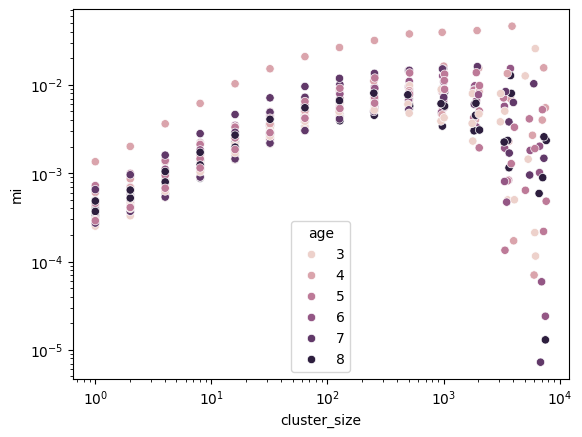

In [166]:
import seaborn as sns
sns.scatterplot(data=df, x = 'cluster_size', y = 'mi', hue = 'age')
plt.yscale('log')
plt.xscale('log')
plt.show()

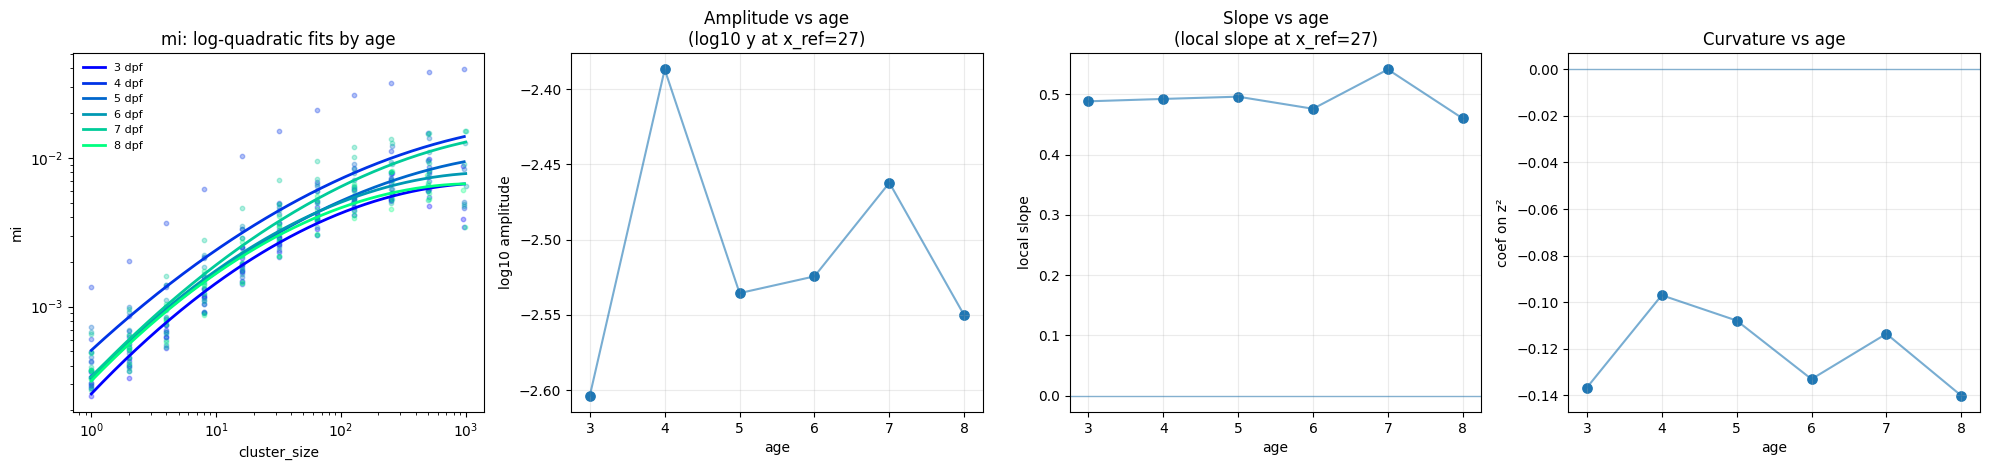

In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --------------------------------------------------
# prep
# --------------------------------------------------
def prep_metric_for_logquad(
    df,
    metric="tau_s",
    xcol="cluster_size",
    fish_id_col="name",
    age_col="age",
    min_obs_per_fish=3,
    max_x=None,
):
    req = [fish_id_col, age_col, xcol, metric]
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    d = df[req].copy()
    d[age_col] = pd.to_numeric(d[age_col], errors="coerce")
    d[xcol] = pd.to_numeric(d[xcol], errors="coerce")
    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    d = d.dropna()

    # log-log fit needs positive values
    d = d[(d[xcol] > 0) & (d[metric] > 0)].copy()

    # restrict x-range
    if max_x is not None:
        d = d[d[xcol] <= max_x].copy()

    # aggregate within fish at each x
    d2 = (
        d.groupby([fish_id_col, age_col, xcol], as_index=False)
         .agg(y=(metric, "mean"))
    )

    # require enough x-points per fish
    keep = d2.groupby(fish_id_col).size()
    keep = keep[keep >= min_obs_per_fish].index
    d2 = d2[d2[fish_id_col].isin(keep)].copy()

    return d2


# --------------------------------------------------
# fit one age
# log10(y) ~ a + b*z + c*z^2
# where z = log10(x) - lx_ref
# --------------------------------------------------
def fit_log_quadratic_per_age(dd, xcol="cluster_size", lx_ref=None):
    d2 = dd.copy()
    d2["lx"] = np.log10(d2[xcol].values)
    d2["ly"] = np.log10(d2["y"].values)

    if lx_ref is None:
        lx_ref = d2["lx"].mean()

    d2["z"] = d2["lx"] - lx_ref
    d2["z2"] = d2["z"]**2

    m = smf.ols("ly ~ z + z2", data=d2).fit()

    xfit = np.logspace(np.log10(d2[xcol].min()), np.log10(d2[xcol].max()), 200)
    lxfit = np.log10(xfit)
    zfit = lxfit - lx_ref
    yfit = 10 ** m.predict(pd.DataFrame({"z": zfit, "z2": zfit**2}))

    curve = pd.DataFrame({xcol: xfit, "pred": yfit})

    logA_ref = m.params.get("Intercept", np.nan)
    A_ref = 10**logA_ref
    slope_ref = m.params.get("z", np.nan)
    curvature = m.params.get("z2", np.nan)

    return m, curve, {
        "lx_ref": lx_ref,
        "x_ref": 10**lx_ref,
        "logA_ref": logA_ref,
        "A_ref": A_ref,
        "slope_ref": slope_ref,
        "curvature": curvature,
    }


# --------------------------------------------------
# main plot
# --------------------------------------------------
def plot_age_logquad_metric(
    df,
    metric="tau_s",
    xcol="cluster_size",
    fish_id_col="name",
    age_col="age",
    min_obs_per_fish=3,
    min_fish_per_age=2,
    max_x=None,
):
    d = prep_metric_for_logquad(
        df,
        metric=metric,
        xcol=xcol,
        fish_id_col=fish_id_col,
        age_col=age_col,
        min_obs_per_fish=min_obs_per_fish,
        max_x=max_x,
    )

    ages = np.sort(d[age_col].unique())
    cmap = plt.get_cmap("winter", len(ages))

    lx_ref = np.log10(d[xcol]).mean()
    x_ref = 10**lx_ref

    fig, axes = plt.subplots(1, 4, figsize=(20, 4.8))
    ax_fit, ax_amp, ax_slope, ax_curv = axes

    rows = []

    for k, age in enumerate(ages):
        dd = d[d[age_col] == age].copy()
        if dd[fish_id_col].nunique() < min_fish_per_age:
            continue

        col = cmap(k)

        ax_fit.scatter(dd[xcol], dd["y"], s=10, alpha=0.3, color=col)

        m, curve, out = fit_log_quadratic_per_age(dd, xcol=xcol, lx_ref=lx_ref)
        ax_fit.plot(curve[xcol], curve["pred"], lw=2, color=col, label=f"{int(age)} dpf")

        rows.append({
            "age": age,
            "logA_ref": out["logA_ref"],
            "A_ref": out["A_ref"],
            "slope_ref": out["slope_ref"],
            "curvature": out["curvature"],
            "n_fish": dd[fish_id_col].nunique(),
        })

    coeffs = pd.DataFrame(rows).sort_values("age")

    ax_amp.scatter(coeffs["age"], coeffs["logA_ref"], s=45)
    ax_amp.plot(coeffs["age"], coeffs["logA_ref"], alpha=0.6)
    ax_amp.set_title(f"Amplitude vs age\n(log10 y at x_ref={x_ref:.2g})")
    ax_amp.set_xlabel("age")
    ax_amp.set_ylabel("log10 amplitude")
    ax_amp.grid(True, alpha=0.25)

    ax_slope.scatter(coeffs["age"], coeffs["slope_ref"], s=45)
    ax_slope.plot(coeffs["age"], coeffs["slope_ref"], alpha=0.6)
    ax_slope.axhline(0, lw=1, alpha=0.5)
    ax_slope.set_title(f"Slope vs age\n(local slope at x_ref={x_ref:.2g})")
    ax_slope.set_xlabel("age")
    ax_slope.set_ylabel("local slope")
    ax_slope.grid(True, alpha=0.25)

    ax_curv.scatter(coeffs["age"], coeffs["curvature"], s=45)
    ax_curv.plot(coeffs["age"], coeffs["curvature"], alpha=0.6)
    ax_curv.axhline(0, lw=1, alpha=0.5)
    ax_curv.set_title("Curvature vs age")
    ax_curv.set_xlabel("age")
    ax_curv.set_ylabel("coef on z²")
    ax_curv.grid(True, alpha=0.25)

    ax_fit.set_xscale("log")
    ax_fit.set_yscale("log")
    ax_fit.set_xlabel(xcol)
    ax_fit.set_ylabel(metric)
    ax_fit.set_title(f"{metric}: log-quadratic fits by age")
    ax_fit.legend(frameon=False, fontsize=8)

    plt.tight_layout()
    plt.show()

    return coeffs


# run
coeffs_quad = plot_age_logquad_metric(
    df,
    metric="mi",
    xcol="cluster_size",
    fish_id_col="fish",
    age_col="age",
    max_x=1000,
)

# Process

In [124]:
#Process all! 
#=================
fdata = '/home/dburrows/DATA/BLNDEV-WILDTYPE/'
icg_dir = os.path.join(fdata, "icg_npy")
icg_files = np.sort(glob.glob(os.path.join(icg_dir, "*_icg_greedy.npy")))

# sampling rate (your data: 2.73 Hz)
fs = 2.73
dt = 1.0 / fs

rows = []
for p in tqdm(icg_files):
    payload = np.load(p, allow_pickle=True).item()

    gens = np.asarray(payload["generations"], dtype=int)
    traces_by_gen = payload["mean_traces_by_gen"]  # object array, len=G
    fish = fish_id_from_path(payload.get("source_path", p))
    age  = parse_age_dpf(payload.get("source_path", p))
    sizes = payload['sizes_by_gen']

    for gi, g in enumerate(gens[:-1]):
        if gi ==0: start = traces_by_gen[gi].shape[0]
        Xg = np.asarray(traces_by_gen[gi], dtype=np.float32)  # (K,T)
        
        kurt = kurtosis_corr(Xg)    
        mv, scaled_mv = mean_variance(Xg, Xg.shape[0], np.round(start/int(Xg.shape[0])))
        tau = timescale(Xg, max_lag=3, dt=dt)
        mi, pairs, B = sampled_pairwise_binary_mi(Xg, threshold=1.96, per_trace_zscore=True, n_pairs=100000)
        mean_mi = np.nanmean(mi)
        

        rows.append({
            "fish": fish,
            "age": int(age),
            "gen": int(g),
            "n_clusters": int(Xg.shape[0]),
            "cluster_size": np.round(start/int(Xg.shape[0])),
            "kurtosis_corr": kurt,
            "var": mv,
            "scaled_var": scaled_mv,
            "tau_s": tau,
            "mi":mean_mi
        })

df_icg = pd.DataFrame(rows)
out_csv = os.path.join(fdata, "NEW_icg_metrics_by_fish_gen.csv")
df_icg.to_csv(out_csv, index=False)
print("Saved:", out_csv)
print(df_icg.head())

  0%|                                                                           | 0/30 [00:00<?, ?it/s]/tmp/ipykernel_2062174/1527053791.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ac_mean, t))
100%|██████████████████████████████████████████████████████████████████| 30/30 [06:06<00:00, 12.23s/it]

Saved: /home/dburrows/DATA/BLNDEV-WILDTYPE/NEW_icg_metrics_by_fish_gen.csv
                 fish  age  gen  n_clusters  cluster_size  kurtosis_corr  \
0  BLNDEV-WILDTYPE-01    4    0       15105           1.0      11.254332   
1  BLNDEV-WILDTYPE-01    4    1        7553           2.0       7.605207   
2  BLNDEV-WILDTYPE-01    4    2        3777           4.0       5.929494   
3  BLNDEV-WILDTYPE-01    4    3        1889           8.0       4.751653   
4  BLNDEV-WILDTYPE-01    4    4         945          16.0       3.899252   

         var   scaled_var     tau_s        mi  
0  62.916451    62.916451  0.694566  0.000429  
1  35.082905   140.331619  0.811703  0.000620  
2  20.812727   333.003632  0.983104  0.000991  
3  13.188332   844.053223  1.209666  0.001589  
4   8.982278  2299.463135  1.478070  0.002472  


In [175]:
dff_l  = np.sort(glob.glob(f"{fdata}/*regdeltaff*"))
bind_l  = np.sort(glob.glob(f"{fdata}/*regbin*"))
len(dff_l), len(bind_l)

(30, 30)

In [184]:
import os, re
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import multiprocessing as mp

# -------------------------
# filename parsers
# -------------------------
def parse_fish_id(path: str) -> str:
    base = os.path.basename(path)
    m = re.search(r"(BLNDEV-WILDTYPE-\d+)", base)
    return m.group(1) if m else base.split("_")[0]

def parse_age_dpf(path: str) -> int:
    base = os.path.basename(path)
    m = re.search(r"(\d+)\s*dpf", base, flags=re.IGNORECASE) or re.search(r"(\d+)dpf", base, flags=re.IGNORECASE)
    return int(m.group(1)) if m else np.nan


# -------------------------
# your metrics
# -------------------------
def mean_variance(data, ntrace, K):
    if data.size < 10:
        return np.nan, np.nan
    var = np.sum(np.var(data, axis=1)) / ntrace
    return var, var * K**2


def mean_variance_exact_from_means(data, sizes):
    if data.size < 10:
        return np.nan
    var_per_cluster = np.var(data, axis=1)
    sizes = np.asarray(sizes, dtype=float)
    return np.mean((sizes**2) * var_per_cluster)


def kurtosis_corr(data):
    corr = np.corrcoef(data)
    x = corr[np.triu_indices(corr.shape[0], k=1)]

    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size < 10:
        return np.nan

    m = x.mean()
    v = x.var()
    if v <= 0:
        return np.nan

    return np.mean((x - m) ** 4) / (v ** 2)


# -------------------------
# null models
# -------------------------
def null_independent_temporal_shuffle(dff: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    N, T = dff.shape
    out = np.empty_like(dff)
    for i in range(N):
        out[i] = dff[i, rng.permutation(T)]
    return out

def null_independent_circular_permutation(dff: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    N, T = dff.shape
    out = np.empty_like(dff)
    shifts = rng.integers(0, T, size=N)
    for i, s in enumerate(shifts):
        out[i] = np.roll(dff[i], int(s))
    return out

def null_dependent_temporal_shuffle(dff: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    T = dff.shape[1]
    perm = rng.permutation(T)
    return dff[:, perm].copy()


# -------------------------
# subsampling helper
# -------------------------
def subsample_cells(X: np.ndarray, rng: np.random.Generator, frac_cells=0.10, min_cells=50):
    N = X.shape[0]
    n_keep = max(int(np.floor(frac_cells * N)), min_cells)
    n_keep = min(n_keep, N)
    idx = rng.choice(N, size=n_keep, replace=False)
    return X[idx], idx


# -------------------------
# worker for one fish
# -------------------------
def _process_one_fish(args):
    """
    One worker handles one path and returns a list of row dicts.
    """
    (
        p,
        n_gen,
        n_sims,
        frac_cells,
        min_cells,
        Kmin_clusters,
        seed,
        eps,
    ) = args

    null_kinds = [
        ("real", None),
        ("indep_shuffle", null_independent_temporal_shuffle),
        ("indep_circperm", null_independent_circular_permutation),
        ("dep_shuffle", null_dependent_temporal_shuffle),
    ]

    rows = []

    dff0 = np.load(p)
    N, T = dff0.shape

    fish = parse_fish_id(p)
    age = parse_age_dpf(p)
    fish_uid = f"{fish}_{int(age) if np.isfinite(age) else 'NA'}"

    # fish-specific RNG seed so runs are reproducible regardless of pool scheduling
    fish_seed = (abs(hash((p, int(seed)))) % (2**32 - 1))
    rng_master = np.random.default_rng(fish_seed)

    for null_name, null_fn in null_kinds:
        sims = int(n_sims)

        for sim in range(sims):
            rng = np.random.default_rng(rng_master.integers(0, 2**32 - 1))

            # apply null first, then subsample
            if null_fn is None:
                X0 = dff0
            else:
                X0 = null_fn(dff0, rng)

            X, idx = subsample_cells(X0, rng, frac_cells=frac_cells, min_cells=min_cells)
            N_sub = X.shape[0]

            generations, labels_by_gen, mean_traces_by_gen, sizes_by_gen = icg_greedy_fast(
                X,
                n_gen=n_gen,
                eps=eps,
                keep_singletons=True,
                return_gen0=True,
                verbose=False
            )

            for gi, g in enumerate(generations):
                mt = mean_traces_by_gen[gi]
                sizes = np.asarray(sizes_by_gen[gi], dtype=float)
                Kg = int(mt.shape[0])

                if Kmin_clusters is not None and Kg < int(Kmin_clusters):
                    continue

                mean_ensemble_size = float(np.mean(sizes))
                x_mean_size_gen = mean_ensemble_size
                K_approx = mean_ensemble_size

                mv_mean, mv_sum_approx = mean_variance(mt, ntrace=Kg, K=K_approx)
                mv_sum_exact = mean_variance_exact_from_means(mt, sizes)
                kurt = kurtosis_corr(mt)

                rows.append({
                    "fish": fish,
                    "age": int(age) if np.isfinite(age) else np.nan,
                    "id": fish_uid,
                    "null": null_name,
                    "sim": int(sim),
                    "gen": int(g),
                    "n_cells": int(N),
                    "n_cells_sub": int(N_sub),
                    "n_clusters": int(Kg),
                    "mean_ensemble_size": mean_ensemble_size,
                    "x_mean_size_gen": x_mean_size_gen,
                    "cluster_size": float(2**g),
                    "kurtosis_corr": float(kurt) if np.isfinite(kurt) else np.nan,
                    "mean_var_mean": float(mv_mean) if np.isfinite(mv_mean) else np.nan,
                    "mean_var_sum_approx": float(mv_sum_approx) if np.isfinite(mv_sum_approx) else np.nan,
                    "mean_var_sum_exact": float(mv_sum_exact) if np.isfinite(mv_sum_exact) else np.nan,
                    "source_path": p,
                })

            if null_fn is not None:
                del X0
            del X

    del dff0
    return rows


# -------------------------
# multiprocess runner
# -------------------------
def run_icg_nulls_to_df_var_kurt_mp(
    dff_paths,
    n_gen=12,
    n_sims=10,
    frac_cells=1.0,
    min_cells=50,
    Kmin_clusters=None,
    seed=0,
    eps=1e-6,
    n_cores=5,
    out_csv=None,
    chunksize=1,
):
    """
    Multiprocess version. One fish per task, combine everything into one DataFrame.
    """
    job_args = [
        (p, n_gen, n_sims, frac_cells, min_cells, Kmin_clusters, seed, eps)
        for p in dff_paths
    ]

    all_rows = []

    # On Linux/Jupyter, fork is usually easiest for notebook-defined functions.
    # If fork is unavailable, this falls back to default context.
    try:
        ctx = mp.get_context("fork")
    except ValueError:
        ctx = mp.get_context()

    with ctx.Pool(processes=n_cores) as pool:
        for rows in tqdm(
            pool.imap_unordered(_process_one_fish, job_args, chunksize=chunksize),
            total=len(job_args),
            desc="Fish"
        ):
            all_rows.extend(rows)

    df_out = pd.DataFrame(all_rows)

    if out_csv is not None:
        out_dir = os.path.dirname(out_csv)
        if out_dir:
            os.makedirs(out_dir, exist_ok=True)
        df_out.to_csv(out_csv, index=False)

    return df_out

In [186]:
1

1

In [185]:
out_csv = os.path.join(fdata, "icg_null_summary_var_kurt_subsampled_mp.csv")

df_null = run_icg_nulls_to_df_var_kurt_mp(
    dff_l,
    n_gen=12,
    n_sims=10,
    frac_cells=1.0,
    min_cells=50,
    Kmin_clusters=None,
    seed=0,
    eps=1e-6,
    n_cores=5,
    out_csv=out_csv,
    chunksize=1,
)

print(df_null.head())
print("Saved:", out_csv)

Fish:   0%|          | 0/30 [00:00<?, ?it/s]

                 fish  age                    id  null  sim  gen  n_cells  \
0  BLNDEV-WILDTYPE-01    5  BLNDEV-WILDTYPE-01_5  real    0    0    14559   
1  BLNDEV-WILDTYPE-01    5  BLNDEV-WILDTYPE-01_5  real    0    1    14559   
2  BLNDEV-WILDTYPE-01    5  BLNDEV-WILDTYPE-01_5  real    0    2    14559   
3  BLNDEV-WILDTYPE-01    5  BLNDEV-WILDTYPE-01_5  real    0    3    14559   
4  BLNDEV-WILDTYPE-01    5  BLNDEV-WILDTYPE-01_5  real    0    4    14559   

   n_cells_sub  n_clusters  mean_ensemble_size  x_mean_size_gen  cluster_size  \
0        14559       14559            1.000000         1.000000           1.0   
1        14559        7280            1.999863         1.999863           2.0   
2        14559        3640            3.999725         3.999725           4.0   
3        14559        1820            7.999451         7.999451           8.0   
4        14559         910           15.998901        15.998901          16.0   

   kurtosis_corr  mean_var_mean  mean_var_sum_appr

In [ ]:
# correlation subsampling + timescale params
max_corr_units = 2000   # reduce if RAM is tight
max_lag_sec = 3.0       # match their "integral up to ~3s" idea
max_lag = int(round(max_lag_sec * fs))

rows = []
for p in tqdm(icg_files):
    payload = np.load(p, allow_pickle=True).item()

    gens = np.asarray(payload["generations"], dtype=int)
    traces_by_gen = payload["mean_traces_by_gen"]  # object array, len=G

    fish = fish_id_from_path(payload.get("source_path", p))
    age  = parse_age_dpf(payload.get("source_path", p))

    for gi, g in enumerate(gens):
        Xg = np.asarray(traces_by_gen[gi], dtype=np.float32)  # (K,T)

        # kurtosis of correlation distribution (offdiag)
        vals = corr_offdiag_vals(Xg, max_units=max_corr_units, seed=gi)
        krt  = kurtosis_plain(vals)

        # mean variance across clusters
        mv = mean_variance_across_clusters(Xg)

        # mean timescale across clusters (seconds)
        mtau = mean_timescale_across_clusters(Xg, max_lag=max_lag, dt=dt)

        rows.append({
            "fish": fish,
            "age": age,
            "gen": int(g),
            "n_clusters": int(Xg.shape[0]),
            "kurtosis_corr": krt,
            "mean_var": mv,
            "mean_tau_s": mtau,
        })

df_icg = pd.DataFrame(rows)
df_icg = df_icg.dropna(subset=["age"]).copy()
df_icg["age"] = df_icg["age"].astype(int)

out_csv = os.path.join(fdata, "icg_metrics_by_fish_gen.csv")
df_icg.to_csv(out_csv, index=False)
print("Saved:", out_csv)
print(df_icg.head())

# ============================================================
# Example: aggregate across fish per age × gen for quick look
# ============================================================
# agg = (df_icg.groupby(["age","gen"], as_index=False)
#            .agg(kurtosis_corr=("kurtosis_corr","median"),
#                 mean_var=("mean_var","median"),
#                 mean_tau_s=("mean_tau_s","median"),
#                 n_fish=("fish","nunique"),
#                 n_clusters=("n_clusters","median")))
# display(agg.head())

In [ ]:
def kurtosis_plain(x):
    """Kurtosis (not excess): E[(x-m)^4]/std^4. Returns nan if degenerate."""
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size < 10:
        return np.nan
    m = x.mean()
    v = x.var()
    if v <= 0:
        return np.nan
    return np.mean((x - m) ** 4) / (v ** 2)

fdata = "/home/dburrows/DATA/BLNDEV-WILDTYPE"


import os, re, glob
import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================================
# Load per-fish ICG outputs (.npy payload dict) and compute:
#   - kurtosis of off-diagonal correlation distribution (per generation)
#   - mean variance of cluster mean-traces (per generation)
#   - mean timescale (mean autocorr integral up to max_lag) (per generation)
# Then save a long dataframe: one row per fish × age × generation
# ============================================================

# ----------------------------
# Helpers you likely already have
# ----------------------------
def parse_age_dpf(path):
    # expects "...-4dpf..." or "... 4dpf ..." etc; adjust to your filename convention
    m = re.search(r"(\d+)\s*dpf", path)
    if m:
        return int(m.group(1))
    m = re.search(r"(\d+)dpf", path)
    return int(m.group(1)) if m else np.nan

def fish_id_from_path(p):
    b = os.path.basename(p)
    m = re.search(r"(BLNDEV-WILDTYPE-\d+)", b)
    return m.group(1) if m else os.path.splitext(b)[0]

# ----------------------------
# Stats helpers
# ----------------------------
def kurtosis_plain(x):
    """Kurtosis (not excess): E[(x-m)^4]/std^4. Returns nan if degenerate."""
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size < 10:
        return np.nan
    m = x.mean()
    v = x.var()
    if v <= 0:
        return np.nan
    return np.mean((x - m) ** 4) / (v ** 2)

def zscore_rows(X, eps=1e-6):
    X = np.asarray(X, dtype=np.float32)
    Xc = X - X.mean(axis=1, keepdims=True)
    Xn = Xc / (Xc.std(axis=1, keepdims=True) + eps)
    return Xn

def corr_offdiag_vals(X, max_units=2000, seed=0):
    """
    Off-diagonal Pearson correlations for row-traces in X (K,T).
    Subsamples rows if K large to keep K^2 manageable.
    """
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=np.float32)
    K, T = X.shape

    if K < 3:
        return np.array([], dtype=np.float32)

    if K > max_units:
        idx = rng.choice(K, size=max_units, replace=False)
        X = X[idx]
        K = max_units

    Xn = zscore_rows(X)
    C = (Xn @ Xn.T) / float(T)
    iu = np.triu_indices(K, k=1)
    vals = C[iu]
    vals = vals[np.isfinite(vals)]
    return vals

def mean_variance_across_clusters(X):
    """Mean variance across cluster mean-traces (variance over time per row)."""
    X = np.asarray(X, dtype=np.float32)
    if X.size == 0:
        return np.nan
    v = X.var(axis=1)  # per cluster
    return float(np.nanmean(v))

def mean_autocorr_curve(X, max_lag_frames=200, eps=1e-8):
    """
    X: (N_l, T) cluster traces at scale l
    Returns:
      ac_mean: (L+1,) mean autocorr across clusters, ac_mean[0]=1
    """
    X = np.asarray(X, dtype=np.float64)
    N, T = X.shape
    L = min(max_lag_frames, T - 2)
    if N < 1 or L < 1:
        return None

    ac_sum = np.zeros(L + 1, dtype=np.float64)
    n_used = 0

    for i in range(N):
        x = X[i]
        if not np.all(np.isfinite(x)):
            x = x[np.isfinite(x)]
        if x.size < L + 2:
            continue

        x = x - x.mean()
        v = x.var(ddof=0)
        if v < eps:
            continue
        x = x / np.sqrt(v)  # now var=1, so dot gives correlation

        # ac[lag] = mean_t x[t] x[t+lag]
        ac = np.empty(L + 1, dtype=np.float64)
        ac[0] = 1.0
        for lag in range(1, L + 1):
            ac[lag] = np.dot(x[:-lag], x[lag:]) / (x.size - lag)
        ac_sum += ac
        n_used += 1

    if n_used == 0:
        return None
    return ac_sum / n_used


def timescale_from_mean_autocorr(X, max_lag=3.0, dt=1.0):
    """
    Matches paper: compute mean autocorr across clusters, then AUC (trapezoid).
    max_lag in seconds; dt in seconds.
    """
    max_lag_frames = int(np.floor(max_lag / dt))
    ac_mean = mean_autocorr_curve(X, max_lag_frames=max_lag_frames)
    if ac_mean is None:
        return np.nan


    ac_use = ac_mean

    t = np.arange(ac_use.size) * dt
    tau = np.trapz(ac_use, t)  # area under curve in seconds
    return float(tau)


In [52]:
start = payload['mean_traces_by_gen'][0].shape[0]


In [59]:
np.round(start/6662)

np.float64(2.0)

In [48]:
payload['mean_traces_by_gen'][1].shape

(6662, 4914)

In [50]:
payload['mean_traces_by_gen'][0].shape[0]

13323

In [62]:
# --- paths ---
# fdata = "/Users/k2585057/Library/CloudStorage/Dropbox/PhD/Analysis/Project/BLNDEV-WILDTYPE"
icg_dir = os.path.join(fdata, "icg_npy")
icg_files = np.sort(glob.glob(os.path.join(icg_dir, "*_icg_greedy.npy")))

# sampling rate (your data: 2.73 Hz)
fs = 2.73
dt = 1.0 / fs

# correlation subsampling + timescale params
max_corr_units = 2000   # reduce if RAM is tight
max_lag_sec = 3.0       # match their "integral up to ~3s" idea
max_lag = int(round(max_lag_sec * fs))

rows = []
for p in tqdm(icg_files):
    payload = np.load(p, allow_pickle=True).item()

    gens = np.asarray(payload["generations"], dtype=int)
    traces_by_gen = payload["mean_traces_by_gen"]  # object array, len=G

    fish = fish_id_from_path(payload.get("source_path", p))
    age  = parse_age_dpf(payload.get("source_path", p))

    for gi, g in enumerate(gens):
        if gi ==0: start = traces_by_gen[gi].shape[0]
        Xg = np.asarray(traces_by_gen[gi], dtype=np.float32)  # (K,T)

        # kurtosis of correlation distribution (offdiag)
        vals = corr_offdiag_vals(Xg, max_units=max_corr_units, seed=gi)
        krt  = kurtosis_plain(vals)

        # mean variance across clusters
        mv = mean_variance_across_clusters(Xg)

        # mean timescale across clusters (seconds)
        mtau = mean_timescale_across_clusters(Xg, max_lag=max_lag, dt=dt)

        rows.append({
            "fish": fish,
            "age": age,
            "gen": int(g),
            "n_clusters": int(Xg.shape[0]),
            "cluster_size": np.round(start/int(Xg.shape[0])),
            "kurtosis_corr": krt,
            "mean_var": mv,
            "mean_tau_s": mtau,
        })

df_icg = pd.DataFrame(rows)
df_icg = df_icg.dropna(subset=["age"]).copy()
df_icg["age"] = df_icg["age"].astype(int)

out_csv = os.path.join(fdata, "icg_metrics_by_fish_gen.csv")
df_icg.to_csv(out_csv, index=False)
print("Saved:", out_csv)
print(df_icg.head())

# ============================================================
# Example: aggregate across fish per age × gen for quick look
# ============================================================
# agg = (df_icg.groupby(["age","gen"], as_index=False)
#            .agg(kurtosis_corr=("kurtosis_corr","median"),
#                 mean_var=("mean_var","median"),
#                 mean_tau_s=("mean_tau_s","median"),
#                 n_fish=("fish","nunique"),
#                 n_clusters=("n_clusters","median")))
# display(agg.head())

  0%|                                                                           | 0/30 [00:00<?, ?it/s]


NameError: name 'corr_offdiag_vals' is not defined

# Build model

In [264]:
#Build automata model
n_neurons=1000
ei_ratio = 0.2
e_p_connect=0.1
i_p_connect=0.01
e_w=0.8
i_w = 0.8
p_ext=0.001
refractory_steps=2
dt=0.01
seed=0

rng = np.random.default_rng(seed)
n = n_neurons
e = int(n_neurons - (n_neurons*ei_ratio))
i = int(n_neurons*ei_ratio)
e_p_connect=e_p_connect
i_p_connect=i_p_connect
e_w=e_w
i_w = i_w
p_ext = p_ext
refractory_steps = refractory_steps
dt = dt

In [266]:
# Directed Erdos-Renyi adjacency, no self-connections
A_e = rng.random((e, n)) < e_p_connect #E-> connections
np.fill_diagonal(A_e, False)
A_e = A_e.astype(np.uint8)

A_i = rng.random((i, n)) < i_p_connect #I-> connections
for local_i in range(i):
    global_i = e + local_i
    A_i[local_i, global_i] = 0
A_i = A_i.astype(np.uint8)

# State vector: 0=Q, 1=A, >=2 refractory countdown states
state = np.zeros(n, dtype=np.int16)

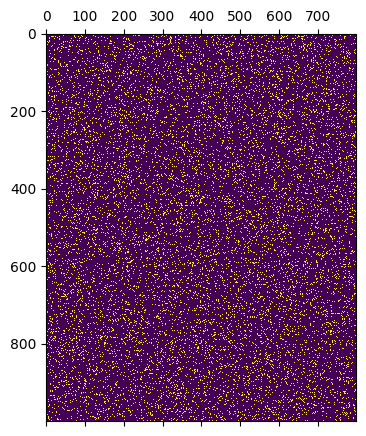

In [267]:
plt.matshow(A_e.T)
plt.show()

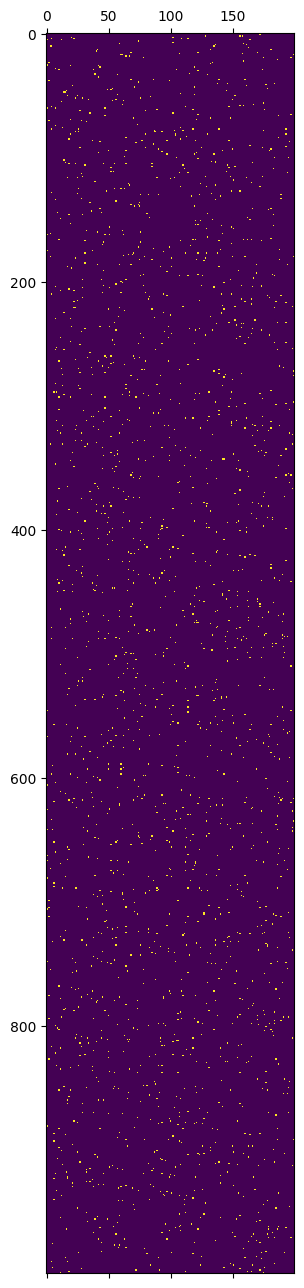

In [268]:
plt.matshow(A_i.T)
plt.show()

In [207]:
state

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [210]:
active.astype(np.float32)[:e]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [269]:
active = (state == 1)

# Network input: number of active presynaptic neurons
inp_e = A_e.T @ active[:e].astype(np.float32)#input from E
inp_i = A_i.T @ active[e:].astype(np.float32) #input from I


# Convert summed E & I into activation probability
#p_net = 1.0 - np.exp(-1* ((e_w * inp_e) - (i_w * inp_i)) )

In [239]:
inp_i[np.random.randint(low=0, high = len(inp_e), size=20)] = 1
inp_e[np.random.randint(low=0, high = len(inp_e), size=30)] = 1

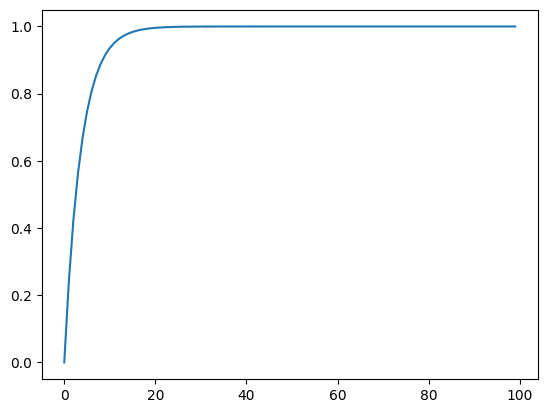

In [244]:
x = np.arange(0,100)
y = 1 - np.exp(-w*x)
plt.plot(x,y)
plt.show()

In [253]:
np.arange(0,100,10)

array([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

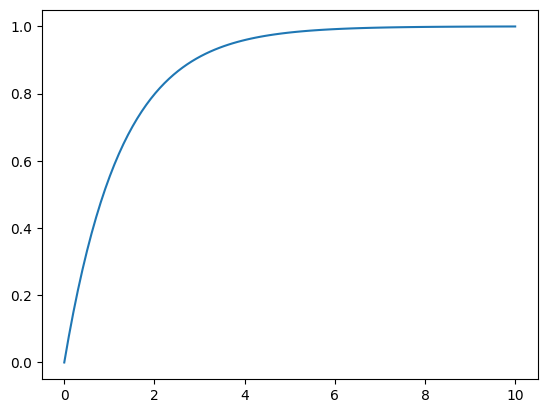

In [263]:
inp_e_prc = 5
inp_i_prc = 0
e_w = 0.8
i_w = 0.8


x = np.linspace(0,10,100)
y = 1.0 - np.exp(-1* ((e_w * x) - (i_w * inp_i_prc)) )
plt.plot(x,y)
plt.show()

Asynchronous: {'mean_rate': np.float64(0.251625), 'std_rate': np.float64(0.1674734587180906), 'cv_pop': np.float64(0.6655676451760559), 'fano_pop': np.float64(0.11146491554848896), 'lag1_autocorr': np.float64(0.37462871534010006)}


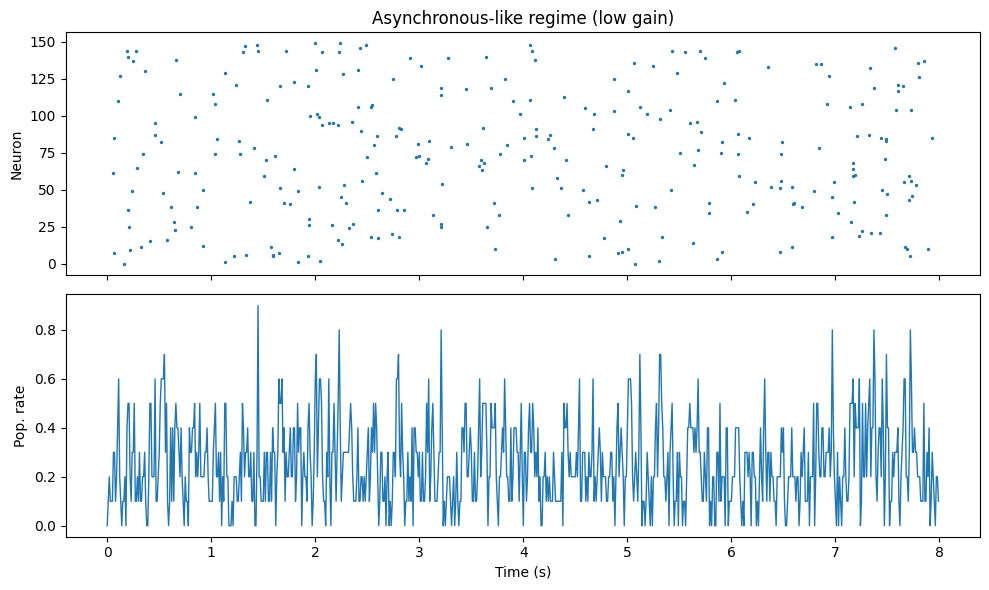

Synchronous: {'mean_rate': np.float64(9.461625), 'std_rate': np.float64(1.6152445199953473), 'cv_pop': np.float64(0.17071533906651096), 'fano_pop': np.float64(0.27574701590632944), 'lag1_autocorr': np.float64(0.8103878342489917)}


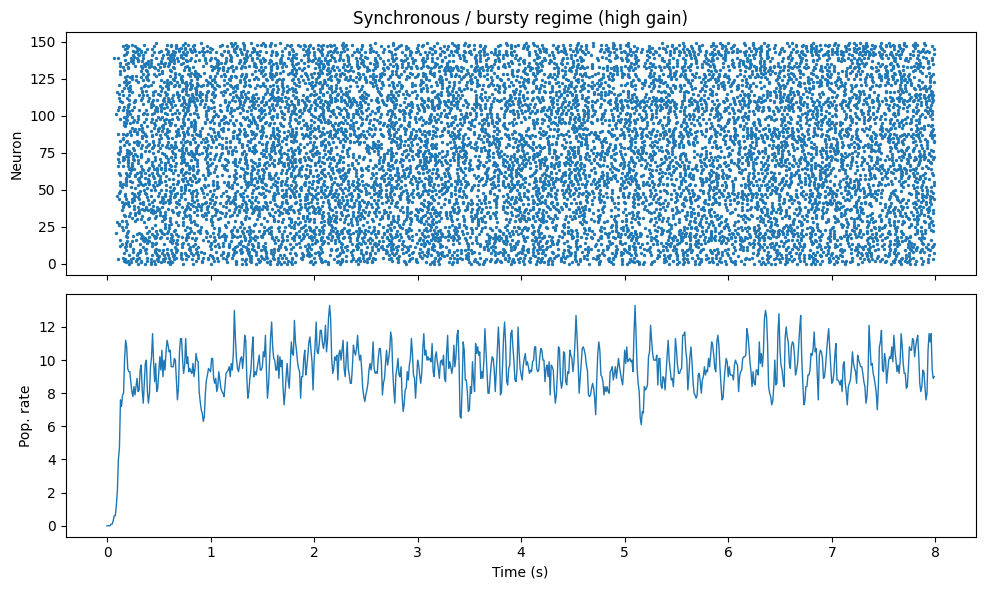

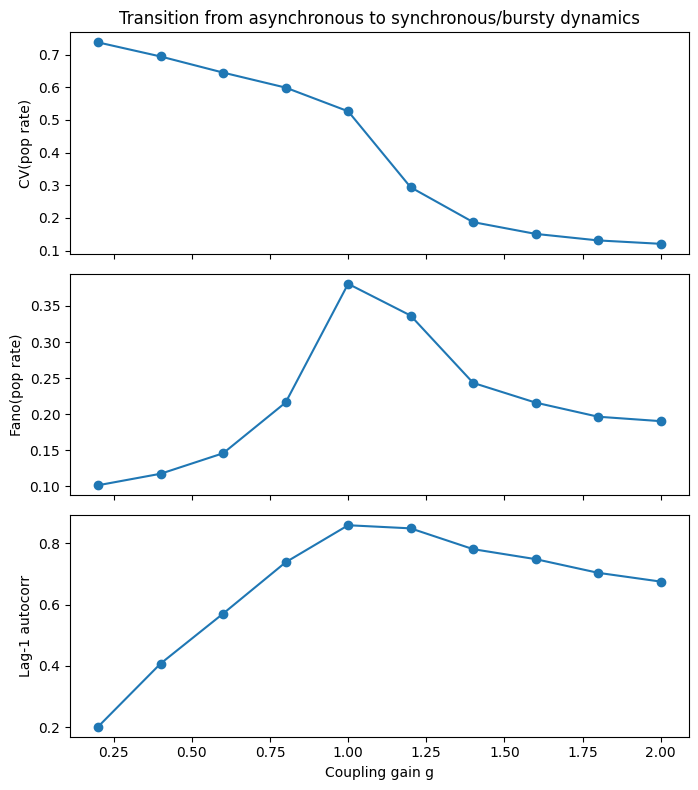

In [3]:
class automata_EI:
    """
    3-state EI network:
      0 = quiescent
      1 = active
      2..(refractory_steps+1) = refractory countdown

    A quiescent neuron can become active from:
      - external Poisson-like drive p_ext
      - network input from active presynaptic neurons

    Network coupling is controlled by g. Higher g -> more synchronous / bursty activity.
    """

    def __init__(
        self,
        n_neurons=1000,
        ei_ratio = 0.2,
        e_p_connect=0.01,
        i_p_connect=0.01,
        e_w=0.8,
        i_w = 0.8,
        p_ext=0.001,
        refractory_steps=2,
        dt=0.01,
        seed=0,
    ):
        self.rng = np.random.default_rng(seed)
        self.n = n_neurons
        self.e = int(n_neurons - (n_neurons*ei_ratio))
        self.i = int(n_neurons*ei_ratio)
        self.e_p_connect=e_p_connect
        self.i_p_connect=i_p_connect
        self.e_w=e_w
        self.i_w = i_w
        self.p_ext = p_ext
        self.refractory_steps = refractory_steps
        self.dt = dt


        #Connect
        
        
        # Directed Erdos-Renyi adjacency, no self-connections
        self.A_e = self.rng.random((self.e, self.n)) < e_p_connect #E-> connections
        np.fill_diagonal(self.A_e, False)
        self.A_e = self.A_e.astype(np.uint8)

        self.A_i = self.rng.random((self.i, self.n)) < i_p_connect #I-> connections
        for local_i in range(self.i):
            global_i = self.e + local_i
            self.A_i[local_i, global_i] = 0
        self.A_i = self.A_i.astype(np.uint8)

        # State vector: 0=Q, 1=A, >=2 refractory countdown states
        self.state = np.zeros(self.n, dtype=np.int16)


    def step(self):
        active = (self.state == 1)

        # Network input: number of active presynaptic neurons
        inp_e = self.A_e.T @ active[:self.e].astype(np.float32)#input from E
        inp_i = self.A_i.T @ active[self.e:].astype(np.float32) #input from I

        

        # Convert summed E & I into activation probability
        p_net = 1.0 - max(1,np.exp(-1* ((self.e_w * inp_e) - (self.i_w * inp_i)) ))

    

        quiescent = (self.state == 0)

        # External drive
        ext_events = self.rng.random(self.n) < self.p_ext

        # Network-driven events
        net_events = self.rng.random(self.n) < p_net

        #make it combinatorial???
        new_active = quiescent & (ext_events | net_events) 

        # Update refractory dynamics
        new_state = np.zeros_like(self.state)

        # Active neurons enter refractory
        new_state[active] = 2

        # Refractory neurons advance countdown
        refractory = self.state >= 2
        new_state[refractory] = self.state[refractory] + 1

        # End refractory after refractory_steps
        done_refrac = new_state > (self.refractory_steps + 1)
        new_state[done_refrac] = 0

        # Newly activated neurons become active
        new_state[new_active] = 1

        self.state = new_state
        return active.astype(np.uint8)

    def run(self, T=10.0, record_subset=200):
        n_steps = int(T / self.dt)


        #Record subset? 
        subset = np.arange(min(record_subset, self.n))

        spikes = np.zeros((len(subset), n_steps), dtype=np.uint8)
        pop_rate = np.zeros(n_steps, dtype=float)

        for t in range(n_steps):
            active = self.step()
            #why subset???
            spikes[:, t] = active[subset] 
            pop_rate[t] = active.mean() / self.dt  # spikes/neuron/sec

        return spikes, pop_rate


def synchrony_metrics(pop_rate):
    """
    A few simple synchrony / burstiness metrics.
    """
    mean_rate = pop_rate.mean()
    std_rate = pop_rate.std()
    cv_pop = std_rate / (mean_rate + 1e-12)
    fano_pop = np.var(pop_rate) / (mean_rate + 1e-12)

    # Pairwise time correlation proxy:
    # normalize population-rate fluctuations
    z = (pop_rate - mean_rate) / (std_rate + 1e-12)
    ac1 = np.corrcoef(z[:-1], z[1:])[0, 1] if len(z) > 1 else np.nan

    return {
        "mean_rate": mean_rate,
        "std_rate": std_rate,
        "cv_pop": cv_pop,
        "fano_pop": fano_pop,
        "lag1_autocorr": ac1,
    }


def plot_raster_and_rate(spikes, pop_rate, dt, title=""):
    t = np.arange(spikes.shape[1]) * dt

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Raster
    ys, xs = np.where(spikes > 0)
    axes[0].scatter(xs * dt, ys, s=2)
    axes[0].set_ylabel("Neuron")
    axes[0].set_title(title)

    # Population rate
    axes[1].plot(t, pop_rate, lw=1)
    axes[1].set_ylabel("Pop. rate")
    axes[1].set_xlabel("Time (s)")

    plt.tight_layout()
    plt.show()


def sweep_gain(
    gains,
    n_repeats=5,
    n_neurons=1000,
    p_connect=0.01,
    p_ext=0.001,
    refractory_steps=2,
    T=20.0,
    dt=0.01,
):
    results = []

    for g in gains:
        metrics_all = []
        for rep in range(n_repeats):
            model = QARNetwork(
                n_neurons=n_neurons,
                p_connect=p_connect,
                g=g,
                p_ext=p_ext,
                refractory_steps=refractory_steps,
                dt=dt,
                seed=rep,
            )
            _, pop_rate = model.run(T=T, record_subset=100)
            metrics_all.append(synchrony_metrics(pop_rate))

        summary = {"g": g}
        for k in metrics_all[0].keys():
            vals = np.array([m[k] for m in metrics_all])
            summary[k + "_mean"] = vals.mean()
            summary[k + "_std"] = vals.std()
        results.append(summary)

    return results


# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------
if __name__ == "__main__":
    dt = 0.01

    # 1) Show one asynchronous regime
    model_async = QARNetwork(
        n_neurons=1000,
        p_connect=0.01,
        g=0.4,          # low effective coupling
        p_ext=0.0015,
        refractory_steps=2,
        dt=dt,
        seed=1,
    )
    spikes_a, rate_a = model_async.run(T=8.0, record_subset=150)
    print("Asynchronous:", synchrony_metrics(rate_a))
    plot_raster_and_rate(spikes_a, rate_a, dt, title="Asynchronous-like regime (low gain)")

    # 2) Show one synchronous regime
    model_sync = QARNetwork(
        n_neurons=1000,
        p_connect=0.01,
        g=1.6,          # high effective coupling
        p_ext=0.0015,
        refractory_steps=2,
        dt=dt,
        seed=2,
    )
    spikes_s, rate_s = model_sync.run(T=8.0, record_subset=150)
    print("Synchronous:", synchrony_metrics(rate_s))
    plot_raster_and_rate(spikes_s, rate_s, dt, title="Synchronous / bursty regime (high gain)")

    # 3) Sweep coupling and quantify transition
    gains = np.linspace(0.2, 2.0, 10)
    results = sweep_gain(
        gains=gains,
        n_repeats=4,
        n_neurons=1000,
        p_connect=0.01,
        p_ext=0.0015,
        refractory_steps=2,
        T=15.0,
        dt=dt,
    )

    g_vals = np.array([r["g"] for r in results])
    cv_vals = np.array([r["cv_pop_mean"] for r in results])
    fano_vals = np.array([r["fano_pop_mean"] for r in results])
    ac_vals = np.array([r["lag1_autocorr_mean"] for r in results])

    fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)
    axes[0].plot(g_vals, cv_vals, marker="o")
    axes[0].set_ylabel("CV(pop rate)")
    axes[0].set_title("Transition from asynchronous to synchronous/bursty dynamics")

    axes[1].plot(g_vals, fano_vals, marker="o")
    axes[1].set_ylabel("Fano(pop rate)")

    axes[2].plot(g_vals, ac_vals, marker="o")
    axes[2].set_ylabel("Lag-1 autocorr")
    axes[2].set_xlabel("Coupling gain g")

    plt.tight_layout()
    plt.show()

Mean connection probability by level:
  level 0: 0.2500
  level 1: 0.1562
  level 2: 0.0977
  level 3: 0.0610
  level 4: 0.0381
  level 5: 0.0238
  level 6: 0.0149


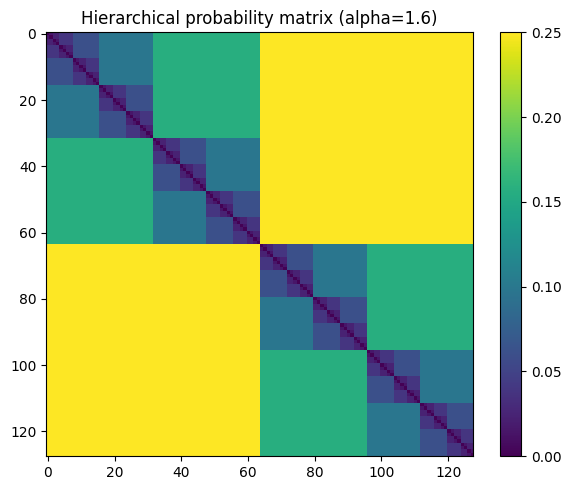

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Dict


def separation_level(i: int, j: int, n_nodes: int) -> int:
    """
    Dyadic hierarchical separation level for nodes i and j.

    Returns:
      0  -> different within pair (finest split)
      1  -> same pair, different within block of 4
      2  -> same block of 4, different within block of 8
      ...
      log2(n_nodes)-1 -> separated only at the coarsest split
    """
    if i == j:
        return -1

    n_levels = int(np.log2(n_nodes))
    xor = i ^ j
    msb_pos = xor.bit_length() - 1   # position of highest differing bit
    level = n_levels - 1 - msb_pos
    return level


def build_hierarchical_probability_matrix(
    n_nodes: int,
    alpha: float,
    p0: float = 1.0,
    self_connections: bool = False,
) -> np.ndarray:
    if n_nodes < 2 or (n_nodes & (n_nodes - 1)) != 0:
        raise ValueError("n_nodes must be a power of 2.")
    if alpha <= 0:
        raise ValueError("alpha must be > 0.")

    P = np.zeros((n_nodes, n_nodes), dtype=float)

    for i in range(n_nodes):
        for j in range(n_nodes):
            if i == j:
                P[i, j] = p0 if self_connections else 0.0
            else:
                l = separation_level(i, j, n_nodes)
                P[i, j] = min(p0 * (alpha ** (-l)), 1.0)

    return P


def sample_directed_adjacency(
    P: np.ndarray,
    seed: Optional[int] = None,
    self_connections: bool = False,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    A = (rng.random(P.shape) < P).astype(np.uint8)
    if not self_connections:
        np.fill_diagonal(A, 0)
    return A


def mean_connection_probability_by_level(P: np.ndarray) -> Dict[int, float]:
    n_nodes = P.shape[0]
    n_levels = int(np.log2(n_nodes))
    out = {}
    for l in range(n_levels):
        vals = []
        for i in range(n_nodes):
            for j in range(n_nodes):
                if i == j:
                    continue
                if separation_level(i, j, n_nodes) == l:
                    vals.append(P[i, j])
        out[l] = float(np.mean(vals)) if vals else np.nan
    return out


def plot_matrix(M: np.ndarray, title: str = ""):
    plt.figure(figsize=(6, 5))
    plt.imshow(M, aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()


# Example
n_nodes = 128
alpha = 1.6
p0 = 0.25

P = build_hierarchical_probability_matrix(n_nodes, alpha, p0)
summary = mean_connection_probability_by_level(P)

print("Mean connection probability by level:")
for level, val in summary.items():
    print(f"  level {level}: {val:.4f}")

plot_matrix(P, title=f"Hierarchical probability matrix (alpha={alpha})")

In [ ]:
# Test scaling values, confirm correct regime

In [ ]:
# Effect of parameters on scaling values

In [ ]:
# Look for criticality -> compare relationship between criticality + scaling

In [ ]:
# Look at functional properties 